In [2]:
import pandas as pd

## Prepare the data

In [2]:
# data = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27.csv")

In [3]:
# data

In [4]:
# data = data.drop_duplicates("attachment_id", keep='first')
# data.reset_index(drop=True, inplace=True)

In [5]:
# data.columns

In [4]:
def get_ladung_predictions(row):
    # first check if the row have updated ladung prediction format
    # check if aftercourt_classification_ladung__class_prob is not null
    if pd.notnull(row.get("aftercourt_classification_ladung__class_prob")):
        prob = row["aftercourt_classification_ladung__class_prob"]
        is_ladung = row["aftercourt_classification_ladung__class_pred"]
        # get params
        slug = row["aftercourt_classification_ladung__slug"]
        debtor_name = row["aftercourt_classification_ladung__debtor_name"]
        summon_date = row["aftercourt_classification_ladung__judicial_summon_date"]
    elif pd.notnull(row.get("aftercourt_classification__aftercourt_type")):
        is_ladung = row["aftercourt_classification__is_aftercourt"]
        prob = None
        slug = row["aftercourt_classification__slug"]
        debtor_name = row["aftercourt_classification__debtor_name"]
        summon_date = row["aftercourt_classification__judicial_summon_date"]
        
    else:
        is_ladung = None
        prob = None
        slug = None
        debtor_name = None
        summon_date = None
    return is_ladung, prob, slug, debtor_name, summon_date

def get_pfub_predictions(row):
    # first check if the row have updated pfub prediction format
    if pd.notnull(row.get("aftercourt_classification_pfub__class_prob")):
        prob = row["aftercourt_classification_pfub__class_prob"]
        is_pfub = row["aftercourt_classification_pfub__class_pred"]
        # get params
        slug = row["aftercourt_classification_pfub__slug"]
        debtor_name = row["aftercourt_classification_pfub__debtor_name"]
    else:
        is_pfub = None
        prob = None
        slug = None
        debtor_name = None
    return is_pfub, prob, slug, debtor_name
    

In [7]:
# # apply the function to the dataframe and create new columns for ladung predictions
# data[["is_ladung", "ladung_prob", "ladung_slug", "ladung_debtor_name", "ladung_summon_date"]] = data.apply(get_ladung_predictions, axis=1, result_type="expand")
# # apply the function to the dataframe and create new columns for pfub predictions
# data[["is_pfub", "pfub_prob", "pfub_slug", "pfub_debtor_name"]] = data.apply(get_pfub_predictions, axis=1, result_type="expand")

In [8]:
# remove_ols = ['aftercourt_classification__aftercourt_type',
#        'aftercourt_classification__debtor_name',
#        'aftercourt_classification__is_aftercourt',
#        'aftercourt_classification__judicial_summon_date',
#        'aftercourt_classification__slug',
#        'aftercourt_classification_ladung__aftercourt_type',
#        'aftercourt_classification_ladung__class_pred',
#        'aftercourt_classification_ladung__class_prob',
#        'aftercourt_classification_pfub__aftercourt_type',
#        'aftercourt_classification_pfub__class_pred',
#        'aftercourt_classification_pfub__class_prob',
#        'aftercourt_classification_ladung__debtor_name',
#        'aftercourt_classification_ladung__judicial_summon_date',
#        'aftercourt_classification_ladung__slug',
#        'aftercourt_classification_pfub__debtor_name',
#        'aftercourt_classification_pfub__slug']
# data.drop(columns=remove_ols, inplace=True)
# data.columns

In [9]:
# data

In [10]:
# data.is_pfub.value_counts()

In [11]:
# # convert is_ladung and is_pfub to boolean
# data["is_ladung"] = data["is_ladung"].apply(lambda x: True if x == "'True'" else False)
# data["is_pfub"] = data["is_pfub"].apply(lambda x: True if x == "'True'" else False)
# # convert probs to flaot
# data["ladung_prob"] = data["ladung_prob"].apply(lambda x: float(x.replace("'", "")) if pd.notnull(x) else None)
# data["pfub_prob"] = data["pfub_prob"].apply(lambda x: float(x.replace("'", "")) if pd.notnull(x) else None)


In [10]:
import sys
sys.path.append('../../')
sys.path.append('../../intent_recognition')

# from utils.intent_recog_utils import apply_text_cleaning, apply_replace_with_tags, apply_tokenization

# data['cleaned_text'] = data['text'].apply(apply_text_cleaning)
# data['text_with_tags'] = data['cleaned_text'].apply(apply_replace_with_tags)
# # data['tokenized'] = data['text_with_tags'].apply(apply_tokenization) vectorizer already doing the tokenization

In [13]:
# data

In [14]:
# data.to_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27_PROCESSED.csv", index=False)
data = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27.csv")

## Run current models on tf-idf features

In [15]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from intent_recognition.src.services.models.aftercourt_tokenizer import ClassificationSpacyLemmaTokenizer

# vectorizer_custom = TfidfVectorizer(
#     tokenizer=ClassificationSpacyLemmaTokenizer()
# )
# vectorizer_custom

tf idf values

In [16]:
import sys
sys.path.append('../../')
sys.path.append('../../intent_recognition')
VEC_PATH = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/vectorizers/vectorizer.dill"
import dill

with open(VEC_PATH, "rb") as f:
    vectorizer = dill.load(f)

# Apply TF-IDF vectorization
print("=" * 60)
print("LOADED VECTORIZER (200 features)")
print("=" * 60)
tfidf_features_200 = vectorizer.transform(data['text_with_tags'])  
print(f"Features shape: {tfidf_features_200.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - tfidf_features_200.nnz / (tfidf_features_200.shape[0] * tfidf_features_200.shape[1])) * 100:.2f}%")

# print("\n" + "=" * 60)
# print("CUSTOM VECTORIZER (full vocabulary)")
# print("=" * 60)
# tfidf_features_custom = vectorizer_custom.fit_transform(data['text_with_tags'])
# print(f"Features shape: {tfidf_features_custom.shape}")
# print(f"Vocabulary size: {len(vectorizer_custom.vocabulary_)}")
# print(f"Sparsity: {(1.0 - tfidf_features_custom.nnz / (tfidf_features_custom.shape[0] * tfidf_features_custom.shape[1])) * 100:.2f}%")
# print("=" * 60)


/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


LOADED VECTORIZER (200 features)
Features shape: (29345, 200)
Vocabulary size: 200
Sparsity: 70.89%


In [17]:
# # save sparse matrix to disk
# from scipy import sparse
# sparse.save_npz("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27_tfidf_features_200.npz", tfidf_features_200)

In [18]:
# read saved tf-idf features
# from scipy import sparse
# tfidf_features_200 = sparse.load_npz("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27_tfidf_features_200.npz")

In [19]:
tfidf_features_200.shape

(29345, 200)

get predictions from ladung and pfub models

In [20]:
# get predictions from current ladung model
import dill
CURRENT_LADUNG_MODEL = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/classification/ladung_rf_classifier.dill"
CURRENT_PFUB_MODEL = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/models/classification/12-01-2026_binary_pfub_rf_classifier_v1.dill"
model_ladung = dill.load(open(CURRENT_LADUNG_MODEL, "rb"))
model_pfub = dill.load(open(CURRENT_PFUB_MODEL, "rb"))

/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [21]:
ladung_probs_current = model_ladung.predict_proba(tfidf_features_200)[:, 1]
pfub_probs_current = model_pfub.predict_proba(tfidf_features_200)[:, 1]

In [22]:

data['ladung_prob_cur'] = ladung_probs_current
data['pfub_prob_cur'] = pfub_probs_current

In [23]:
# # Basic K-Means clustering on 200 features
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# # Determine optimal number of clusters using elbow method and silhouette score
# n_clusters_range = range(3, 12)
# inertias = []
# silhouette_scores = []

# print("Testing different numbers of clusters...")
# for n_clusters in n_clusters_range:
#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
#     cluster_labels = kmeans.fit_predict(tfidf_features_200)
#     inertias.append(kmeans.inertia_)
#     sil_score = silhouette_score(tfidf_features_200, cluster_labels)
#     silhouette_scores.append(sil_score)
#     print(f"n_clusters={n_clusters}: inertia={kmeans.inertia_:.2f}, silhouette={sil_score:.3f}")



In [24]:
# import matplotlib.pyplot as plt

# # 1. Elbow + Silhouette plot
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ax1.plot(list(n_clusters_range), inertias, 'bo-')
# ax1.set_xlabel('Number of Clusters')
# ax1.set_ylabel('Inertia')
# ax1.set_title('Elbow Method')

# ax2.plot(list(n_clusters_range), silhouette_scores, 'ro-')
# ax2.set_xlabel('Number of Clusters')
# ax2.set_ylabel('Silhouette Score')
# ax2.set_title('Silhouette Score vs. Clusters')

# plt.tight_layout()
# plt.show()


In [25]:
# 8 looks good
optimal_n_clusters = 8
kmeans_final = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
data['kmeans_cluster'] = kmeans_final.fit_predict(tfidf_features_200)

print(f"\n{'='*60}")
print(f"Final clustering with {optimal_n_clusters} clusters")
print(f"{'='*60}")
print(data['kmeans_cluster'].value_counts().sort_index())


/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight



Final clustering with 8 clusters
kmeans_cluster
0     652
1    6162
2    3211
3    3643
4    4697
5    3453
6    3243
7    4284
Name: count, dtype: int64


/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/melih.gorgulu/miniconda3/envs/aftercourt-automation/lib/python3.10/site-packages/sklearn/utils/extmath.py:590: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat


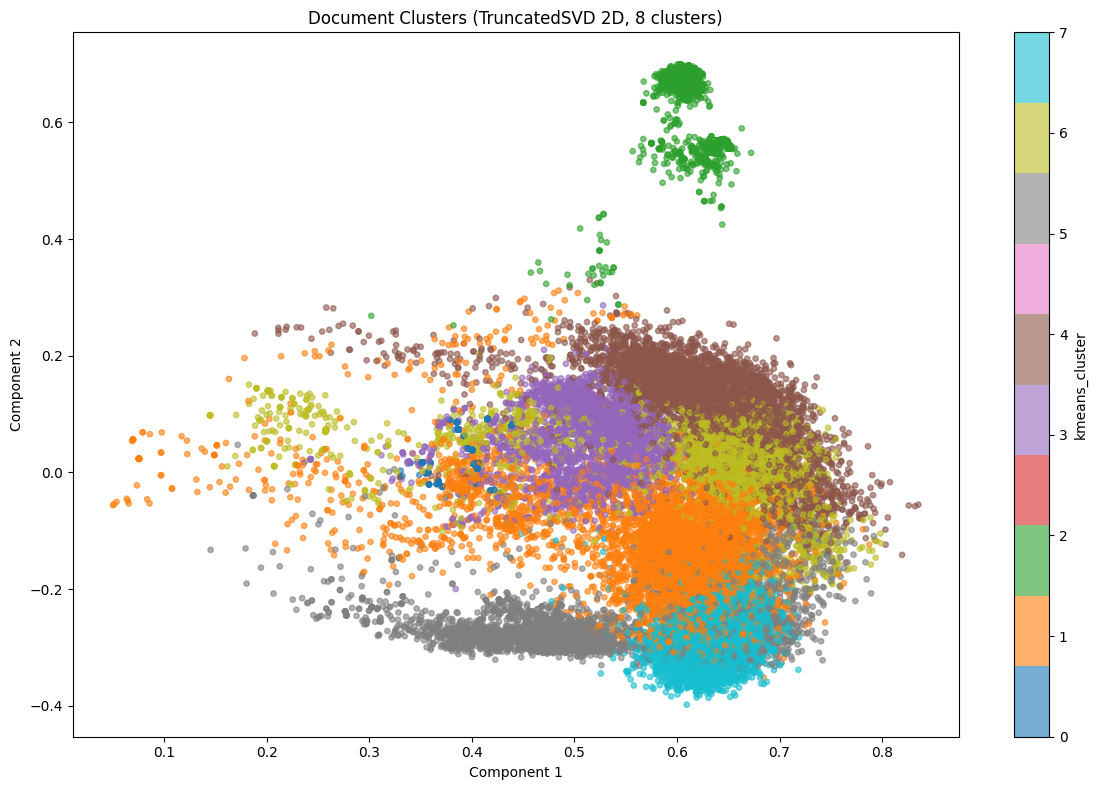

In [26]:
# 2. 2D visualization using TruncatedSVD
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd.fit_transform(tfidf_features_200)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=data['kmeans_cluster'], cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='kmeans_cluster')
ax.set_title(f'Document Clusters (TruncatedSVD 2D, {optimal_n_clusters} clusters)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
plt.tight_layout()
plt.show()

In [27]:
## DBSCAN Clustering

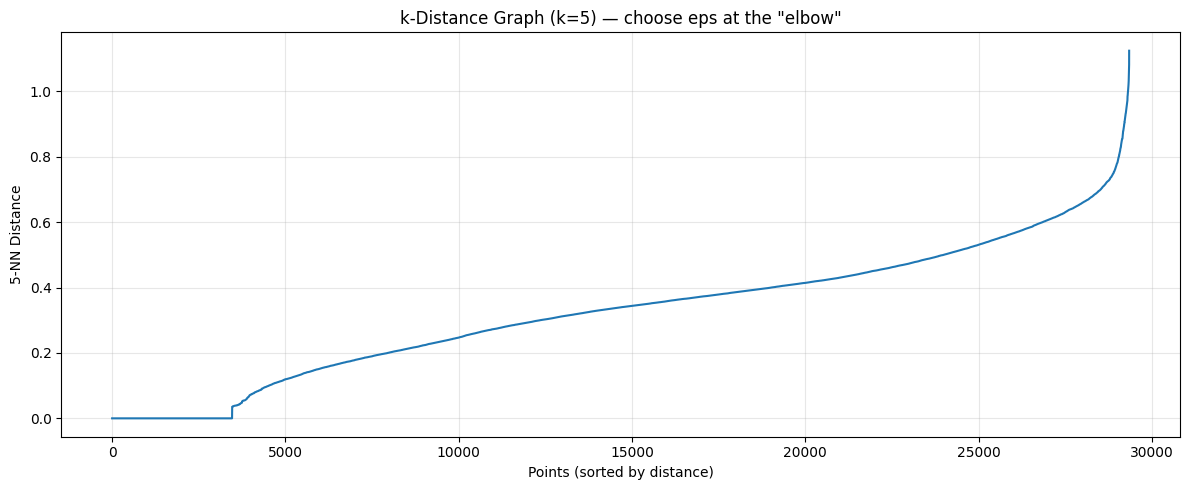

In [28]:
# k-distance plot to find optimal eps
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 5  # min_samples candidate
nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
nn.fit(tfidf_features_200)
distances, _ = nn.kneighbors(tfidf_features_200)
k_distances = np.sort(distances[:, k - 1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_distances)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k}-NN Distance')
ax.set_title(f'k-Distance Graph (k={k}) — choose eps at the "elbow"')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Run DBSCAN — adjust eps based on the k-distance plot elbow
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_value = 0.8   # <-- tune this based on the elbow above
min_samples = 5

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples, metric='euclidean')
data['dbscan_cluster'] = dbscan.fit_predict(tfidf_features_200)

n_clusters_db = len(set(data['dbscan_cluster'])) - (1 if -1 in data['dbscan_cluster'].values else 0)
n_noise = (data['dbscan_cluster'] == -1).sum()

print(f"{'='*60}")
print(f"DBSCAN  (eps={eps_value}, min_samples={min_samples})")
print(f"{'='*60}")
print(f"Clusters found : {n_clusters_db}")
print(f"Noise points   : {n_noise}  ({n_noise / len(data) * 100:.1f}%)")
print(f"\nCluster sizes:")
print(data['dbscan_cluster'].value_counts().sort_index())

# Silhouette score (excluding noise)
noise_mask = (data['dbscan_cluster'] != -1).values  # .values → numpy array for sparse indexing
if noise_mask.sum() > 1 and n_clusters_db > 1:
    score = silhouette_score(tfidf_features_200[noise_mask], data.loc[noise_mask, 'dbscan_cluster'])
    print(f"\nSilhouette score (excl. noise): {score:.3f}")

DBSCAN  (eps=0.8, min_samples=5)
Clusters found : 22
Noise points   : 226  (0.8%)

Cluster sizes:
dbscan_cluster
-1       226
 0     24855
 1        10
 2        17
 3      3285
 4       652
 5        11
 6         7
 7         7
 8         7
 9        22
 10        5
 11        9
 12        6
 13        5
 14        6
 15        7
 16      178
 17        5
 18        5
 19        5
 20        9
 21        6
Name: count, dtype: int64

Silhouette score (excl. noise): 0.106


In [6]:
# data.to_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27.csv", index=False)
data = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27.csv")
data.head()

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,pfub_prob,pfub_slug,pfub_debtor_name,cleaned_text,text_with_tags,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,NaN,NaN,NaN,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,0.01,0.12,4,0,2025-11-21 15:59:17
1,44528763,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528763_DR-II_135225_Nachr_GKB-VAKA_21_11_202...,aa0f9ffd827347c6a5092cfc5eaa6f70616717aa9a42f4...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Neue Büroanschrift ab 01.12.2024\nDortmunder S...,False,NaN,...,NaN,NaN,NaN,neue büroanschrift ab 01.12.2024\ndortmunder s...,neue büroanschrift ab <DATE>\ndortmunder str. ...,0.02,0.06,4,0,2025-11-21 15:59:17
2,44528764,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528764_Protokoll_GKB-EV21_19_11_2025__Gl_.pdf,e9aa64c7f95b93fa63717116455de13d0f6984b4b5aaf6...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,RICHARD STIPP\nDie nachstehend gewählten Formu...,True,NaN,...,NaN,NaN,NaN,richard stipp\ndie nachstehend gewählten formu...,richard stipp\ndie nachstehend gewählten formu...,0.00,0.03,4,0,2025-11-21 15:59:17
3,44528777,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528777_DR-II_050625_Nachr_GKB-HBGA_21_11_202...,769f2c7c81621742ac8cc6fbdc1c308187f7c2f6340cb9...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.02,0.00,4,0,2025-11-21 15:59:17
4,44528778,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528778_DR-II_050625_Nachr_Uebermittlung_elek...,051c81569a38c7d25956fd1a14e983f44830c9f85c87dd...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.38,0.23,1,0,2025-11-21 15:59:17


NameError: name 'coords_2d' is not defined

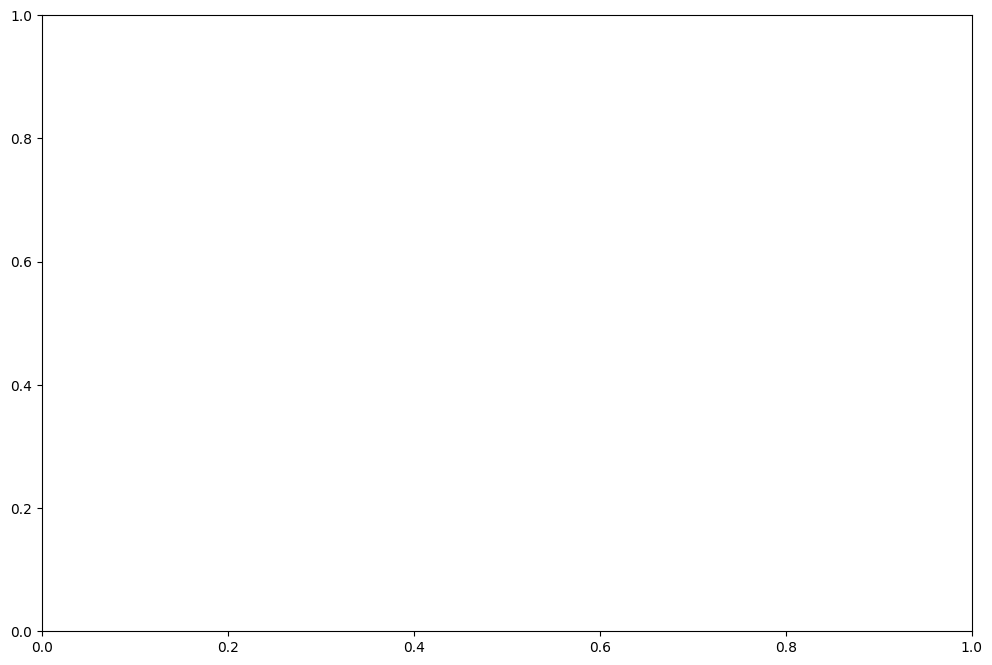

In [7]:
# 2D visualization of DBSCAN clusters (reuse SVD coords from KMeans section)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# Boolean mask as numpy array for indexing
noise = (data['dbscan_cluster'] == -1).values

# Plot noise points first (in grey)
ax.scatter(coords_2d[noise, 0], coords_2d[noise, 1],
           c='lightgrey', alpha=0.4, s=10, label='Noise')

# Plot clustered points
scatter = ax.scatter(coords_2d[~noise, 0], coords_2d[~noise, 1],
                     c=data.loc[~noise, 'dbscan_cluster'], cmap='tab10',
                     alpha=0.6, s=15)
plt.colorbar(scatter, label='dbscan_cluster')
ax.set_title(f'DBSCAN Clusters (eps={eps_value}, min_samples={min_samples}, {n_clusters_db} clusters)')
ax.set_xlabel('SVD Component 1')
ax.set_ylabel('SVD Component 2')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# 3. Top words per cluster (insights)
feature_names = vectorizer.get_feature_names_out()

print("TOP 10 TERMS PER CLUSTER")
print("=" * 60)
for cluster_id in range(optimal_n_clusters):
    cluster_mask = (data['kmeans_cluster'] == cluster_id).values
    cluster_tfidf = tfidf_features_200[cluster_mask]
    mean_tfidf = cluster_tfidf.mean(axis=0).A1  # average TF-IDF per term
    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_indices]
    top_scores = [mean_tfidf[i] for i in top_indices]
    
    print(f"\nCluster {cluster_id} ({cluster_mask.sum()} docs):")
    for term, score in zip(top_terms, top_scores):
        print(f"  {term:<30s} {score:.4f}")

NameError: name 'vectorizer' is not defined

In [11]:
from utils.prod_utils import download_pdf_by_document_s3_info

In [12]:
data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,pfub_prob,pfub_slug,pfub_debtor_name,cleaned_text,text_with_tags,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,NaN,NaN,NaN,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,0.01,0.120000,4,0,2025-11-21 15:59:17
1,44528763,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528763_DR-II_135225_Nachr_GKB-VAKA_21_11_202...,aa0f9ffd827347c6a5092cfc5eaa6f70616717aa9a42f4...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Neue Büroanschrift ab 01.12.2024\nDortmunder S...,False,NaN,...,NaN,NaN,NaN,neue büroanschrift ab 01.12.2024\ndortmunder s...,neue büroanschrift ab <DATE>\ndortmunder str. ...,0.02,0.060000,4,0,2025-11-21 15:59:17
2,44528764,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528764_Protokoll_GKB-EV21_19_11_2025__Gl_.pdf,e9aa64c7f95b93fa63717116455de13d0f6984b4b5aaf6...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,RICHARD STIPP\nDie nachstehend gewählten Formu...,True,NaN,...,NaN,NaN,NaN,richard stipp\ndie nachstehend gewählten formu...,richard stipp\ndie nachstehend gewählten formu...,0.00,0.030000,4,0,2025-11-21 15:59:17
3,44528777,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528777_DR-II_050625_Nachr_GKB-HBGA_21_11_202...,769f2c7c81621742ac8cc6fbdc1c308187f7c2f6340cb9...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.02,0.000000,4,0,2025-11-21 15:59:17
4,44528778,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528778_DR-II_050625_Nachr_Uebermittlung_elek...,051c81569a38c7d25956fd1a14e983f44830c9f85c87dd...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.38,0.230000,1,0,2025-11-21 15:59:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29340,54203493,ocr_source_files/2026-02-27/egvp_id_317018/542...,pair-data-engineering-new,54203493_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,6cc92a56c5f872588c2bc1fd2d5504d130d04decd895cf...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Reutlingen\nVOLLSTRECKUNGSGERICHT\...,False,0.02,...,0.4300,NaN,NaN,amtsgericht reutlingen\nvollstreckungsgericht\...,amtsgericht reutlingen\nvollstreckungsgericht\...,0.04,0.170000,3,0,2026-02-27 06:44:00
29341,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.8475,'184509923993','Eve Stummer',"amtsgericht\nsyke\namtsgericht syke, amtshof 2...","amtsgericht\nsyke\namtsgericht syke, amtshof <...",0.00,0.243333,3,0,2026-02-27 06:44:00
29342,54203581,ocr_source_files/2026-02-27/egvp_id_317022/542...,pair-data-engineering-new,54203581_Dokument_185525_27022026_063106.pdf,4b136029ff45376978a64fa58a71dd94e79f2af7bbd483...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Kai Spitzner\nEuroparatstraße 4\nObergerichtsv...,False,0.05,...,0.0000,NaN,NaN,kai spitzner\neuroparatstraße 4\nobergerichtsv..

## PROD DATA ANALYSIS

In [1]:
import pandas as pd

data = pd.read_csv("/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/notebooks/analysis_data/full_egvp_attachment_data_2025-01-20_to_2025-02-27.csv")
data.head()

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,pfub_prob,pfub_slug,pfub_debtor_name,cleaned_text,text_with_tags,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,NaN,NaN,NaN,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,0.01,0.12,4,0,2025-11-21 15:59:17
1,44528763,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528763_DR-II_135225_Nachr_GKB-VAKA_21_11_202...,aa0f9ffd827347c6a5092cfc5eaa6f70616717aa9a42f4...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Neue Büroanschrift ab 01.12.2024\nDortmunder S...,False,NaN,...,NaN,NaN,NaN,neue büroanschrift ab 01.12.2024\ndortmunder s...,neue büroanschrift ab <DATE>\ndortmunder str. ...,0.02,0.06,4,0,2025-11-21 15:59:17
2,44528764,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528764_Protokoll_GKB-EV21_19_11_2025__Gl_.pdf,e9aa64c7f95b93fa63717116455de13d0f6984b4b5aaf6...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,RICHARD STIPP\nDie nachstehend gewählten Formu...,True,NaN,...,NaN,NaN,NaN,richard stipp\ndie nachstehend gewählten formu...,richard stipp\ndie nachstehend gewählten formu...,0.00,0.03,4,0,2025-11-21 15:59:17
3,44528777,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528777_DR-II_050625_Nachr_GKB-HBGA_21_11_202...,769f2c7c81621742ac8cc6fbdc1c308187f7c2f6340cb9...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.02,0.00,4,0,2025-11-21 15:59:17
4,44528778,ocr_source_files/2025-11-21/egvp_id_263312/445...,pair-data-engineering-new,44528778_DR-II_050625_Nachr_Uebermittlung_elek...,051c81569a38c7d25956fd1a14e983f44830c9f85c87dd...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,CHRISTOPH JOST\nKohlstr. 55\n66450 Bexbach-Höc...,False,NaN,...,NaN,NaN,NaN,christoph jost\nkohlstr. 55\n66450 bexbach-höc...,christoph jost\nkohlstr. <NUMBER>\n<NUMBER> be...,0.38,0.23,1,0,2025-11-21 15:59:17


In [2]:
data.columns

Index(['attachment_id', 'document_s3_key', 'document_s3_bucket', 'file_name',
       'textract_job_id', 'textract_status', 'textract_s3_link', 'text',
       'is_ladung', 'ladung_prob', 'ladung_slug', 'ladung_debtor_name',
       'ladung_summon_date', 'is_pfub', 'pfub_prob', 'pfub_slug',
       'pfub_debtor_name', 'cleaned_text', 'text_with_tags', 'ladung_prob_cur',
       'pfub_prob_cur', 'kmeans_cluster', 'dbscan_cluster', 'created_at'],
      dtype='object')

In [3]:
# sort by created at
data = data.sort_values("created_at").reset_index(drop=True)
data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,pfub_prob,pfub_slug,pfub_debtor_name,cleaned_text,text_with_tags,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,NaN,NaN,NaN,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,gerichtsvollzieher\nag pasewalk\nthomas rex\nz...,0.01,0.120000,4,0,2025-11-21 15:59:17
1,44528842,ocr_source_files/2025-11-21/egvp_id_263329/445...,pair-data-engineering-new,44528842_Dokument_154725_21112025_144339.pdf,0ff17f8cc5a190950a30811e7625188371ba5d4e2d1cab...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...,False,NaN,...,NaN,NaN,NaN,katharina hahn\nherrenstraße 11\nobergerichtsv...,katharina hahn\nherrenstraße <NUMBER>\noberger...,0.06,0.000000,1,0,2025-11-21 15:59:17
2,44528839,ocr_source_files/2025-11-21/egvp_id_263328/445...,pair-data-engineering-new,44528839_9C570_25_KL_LiquandumCapitalIIGmbHges...,c32b59dc85f7db8c5ff2de759f4c0e0e298a0b1d179205...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Marburg\nAmtsgericht, Universitäts...",False,NaN,...,NaN,NaN,NaN,"amtsgericht marburg\namtsgericht, universitäts...","amtsgericht marburg\namtsgericht, universitäts...",0.02,0.190000,3,0,2025-11-21 15:59:17
3,44528833,ocr_source_files/2025-11-21/egvp_id_263326/445...,pair-data-engineering-new,44528833_Dr_ii_1414_25_an_gl_terminsmitteilung...,ee4b8a79acafe9075a7d1bc0ca44fd48190c8d0cce3f12...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieherin Stein\nbeim Amtsgericht D...,True,NaN,...,NaN,NaN,NaN,gerichtsvollzieherin stein\nbeim amtsgericht d...,gerichtsvollzieherin stein\nbeim amtsgericht d...,0.99,0.080000,1,0,2025-11-21 15:59:17
4,44528830,ocr_source_files/2025-11-21/egvp_id_263325/445...,pair-data-engineering-new,44528830_4_dr_ii_1102_25_an_gl_nachricht_hbant...,a41caa2ce1d958be182910462cffad167ab3727320e642...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nMatthias Johann\nBüroz...,True,NaN,...,NaN,NaN,NaN,obergerichtsvollzieher\nmatthias johann\nbüroz...,obergerichtsvollzieher\nmatthias johann\nbüroz...,0.09,0.160000,4,0,2025-11-21 15:59:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29340,54203585,ocr_source_files/2026-02-27/egvp_id_317023/542...,pair-data-engineering-new,54203585_0_sammel1.pdf,8ec3cfb4d1edebcbfaf9ed719228254fa07ced061634f2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...,True,1.00,...,0.0000,NaN,NaN,obergerichtsvollzieherin\namtsgericht: burg\nm...,obergerichtsvollzieherin\namtsgericht: burg\nm...,1.00,0.080000,7,0,2026-02-27 06:44:00
29341,54203493,ocr_source_files/2026-02-27/egvp_id_317018/542...,pair-data-engineering-new,54203493_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,6cc92a56c5f872588c2bc1fd2d5504d130d04decd895cf...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Reutlingen\nVOLLSTRECKUNGSGERICHT\...,False,0.02,...,0.4300,NaN,NaN,amtsgericht reutlingen\nvollstreckungsgericht\...,amtsgericht reutlingen\nvollstreckungsgericht\...,0.04,0.170000,3,0,2026-02-27 06:44:00
29342,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.8475,'184509923993','Eve Stummer',"amtsgericht\nsyke\namtsgericht syke, amtshof 2...","amtsgericht\nsyke\na

In [20]:
data.columns

Index(['attachment_id', 'document_s3_key', 'document_s3_bucket', 'file_name',
       'textract_job_id', 'textract_status', 'textract_s3_link', 'text',
       'is_ladung', 'ladung_prob', 'ladung_slug', 'ladung_debtor_name',
       'ladung_summon_date', 'is_pfub', 'pfub_prob', 'pfub_slug',
       'pfub_debtor_name', 'cleaned_text', 'text_with_tags', 'ladung_prob_cur',
       'pfub_prob_cur', 'kmeans_cluster', 'dbscan_cluster', 'created_at'],
      dtype='object')

In [5]:
def all_params_exist_ladung(row):
    slug = row.get("ladung_slug")
    debtor_name = row.get("ladung_debtor_name")
    summon_date = row.get("ladung_summon_date")
    # all should be not none
    if pd.notnull(slug) and pd.notnull(debtor_name) and pd.notnull(summon_date):
        return True
    return False

def all_params_exist_pfub(row):
    slug = row.get("pfub_slug")
    debtor_name = row.get("pfub_debtor_name")
    # all should be not null
    if pd.notnull(slug) and pd.notnull(debtor_name):
        return True
    return False

data["ladung_all_params_exist"] = data.apply(all_params_exist_ladung, axis=1)
data["pfub_all_params_exist"] = data.apply(all_params_exist_pfub, axis=1)


TH_LADUNG_PROB = 0.95
TH_PFUB_PROB = 0.5

def automized_as_ladung(row):
    # first get ladung prob if its none means it is old model
    ladung_prob = row.get("ladung_prob")
    if pd.notna(ladung_prob):
        # if prob is greater than threshold and all params exist then it is automized as ladung
        if ladung_prob > TH_LADUNG_PROB and all_params_exist_ladung(row):
            return True
        else:
            return False
    else:
        # use prob from current model if ladung_prob is none
        ladung_prob_cur = row.get("ladung_prob_cur")
        if pd.notna(ladung_prob_cur) and ladung_prob_cur > TH_LADUNG_PROB and all_params_exist_ladung(row):
            return True
        
    return False

def is_ladung_with_probs(row):
    # first get ladung prob if its none means it is old model
    ladung_prob = row.get("ladung_prob")
    if pd.notna(ladung_prob):
        # if prob is greater than threshold and all params exist then it is automized as ladung
        if ladung_prob > TH_LADUNG_PROB:
            return True
        else:
            return False
    else:
        # use prob from current model if ladung_prob is none
        ladung_prob_cur = row.get("ladung_prob_cur")
        if pd.notna(ladung_prob_cur) and ladung_prob_cur > TH_LADUNG_PROB:
            return True
        
    return False

def automized_as_pfub(row):
    if row.get("is_pfub") == True and all_params_exist_pfub(row):
        return True
    return False

data['automized_as_ladung'] = data.apply(automized_as_ladung, axis=1)
data['automized_as_pfub'] = data.apply(automized_as_pfub, axis=1)


In [6]:
data['is_ladung_with_probs'] = data.apply(is_ladung_with_probs, axis=1)

In [10]:
february_26_data = data[(data['created_at'] >= "2026-02-26") & (data['created_at'] < "2026-02-27")]
february_26_data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,is_ladung_with_probs
28855,54137269,ocr_source_files/2026-02-26/egvp_id_316139/541...,pair-data-engineering-new,54137269_ZU_VAK.pdf,6852c407c6b7deb8edc056fefc88eddb120f37ec499108...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,SVEN BALTHASAR\nDie nachstehend gewählten Form...,False,0.07,...,0.08,0.05,1,1,2026-02-26 06:44:00,False,False,False,False,False
28856,54137268,ocr_source_files/2026-02-26/egvp_id_316139/541...,pair-data-engineering-new,54137268_Protokoll_GKB-EV21_17_02_2026.pdf,566dba2579adcafcc9a2b18f64456896d0adabd83ceee1...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,SVEN BALTHASAR\nDie nachstehend gewählten Form...,False,0.00,...,0.00,0.00,4,0,2026-02-26 06:44:00,False,False,False,False,False
28857,54137267,ocr_source_files/2026-02-26/egvp_id_316139/541...,pair-data-engineering-new,54137267_DRII-007826_BZSt_Ergebnis_1_17_02_202...,3a220fbfda44262f17ff33412bb5b5c5ac507091ca5af5...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Bundeszentralamt\nfür Steuern\nPOSTANSCHRIFT\n...,False,0.00,...,0.01,0.01,5,0,2026-02-26 06:44:00,False,False,False,False,False
28858,54137266,ocr_source_files/2026-02-26/egvp_id_316139/541...,pair-data-engineering-new,54137266_DR-II_007826_Nachr_Zahlungsaufforderu...,e6ea753871f1529095e184760b7546bfc19df304f9a758...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Friedrichstraße 15\nSVEN BALTHASAR\n39387 Osch...,False,0.38,...,0.36,0.06,4,0,2026-02-26 06:44:00,False,False,False,False,False
28859,54137265,ocr_source_files/2026-02-26/egvp_id_316139/541...,pair-data-engineering-new,54137265_DR-II_007826_Nachr_protokoll_mit_vors...,c8d124a6001d38df8c880c68996202f0005c9ee8a358f0...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Friedrichstraße 15\nSVEN BALTHASAR\n39387 Osch...,False,0.46,...,0.31,0.07,1,0,2026-02-26 06:44:00,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29335,54153975,ocr_source_files/2026-02-26/egvp_id_316978/541...,pair-data-engineering-new,54153975_0_sammel1.pdf,351ad715e32470cda6955860f50c020bda746769341e5c...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Gerichtsvollzieherin\nAG Gladbeck, Schützenstr...",False,0.45,...,0.33,0.06,1,0,2026-02-26 20:44:00,False,False,False,False,False
29336,54153970,ocr_source_files/2026-02-26/egvp_id_316977/541...,pair-data-engineering-new,54153970_DR-II_016326_Nachr_RZ_26_02_2026.pdf,2a13fe273475b6666311e336d6a89ef0cde952b25b5eae...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Hünensand 61\n49716 Meppen\nTel. 05932-504669\...,False,0.47,...,0.27,0.02,1,0,2026-02-26 20:44:00,False,False,False,False,False
29337,54153962,ocr_source_files/2026-02-26/egvp_id_316976/541...,pair-data-engineering-new,54153962_Dokument_23026_26022026_111325.pdf,8ce8a17443f6b900e3fa2e8c5e4ac96c6c6b8501cb8a23...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Elena Growitz\nSchulenburger Landstraße 128\nO...,True,1.00,...,1.00,0.00,7,0,2026-02-26 20:44:00,True,False,True,False,True
29338,54154043,ocr_source_files/2026-02-26/egvp_id_316980/541...,pair-data-engineering-new,54154043_Dr_ii_209_26_erfolglose_ermittlung.pdf,8b81fb2c11888aed7e48acddafed4983901ceea70d3be4...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nIm Gewerbegebiet 13 A ...,False,0.11,...,0.04,0.20,4,0,2026-02-26 21:44:00,False,False,False,False,False


In [12]:
february_26_data.created_at.min(), february_26_data.created_at.max()

('2026-02-26 06:44:00', '2026-02-26 22:44:00')

In [13]:
february_26_data.shape

(485, 29)

In [14]:
february_26_data.automized_as_ladung.value_counts()

automized_as_ladung
False    399
True      86
Name: count, dtype: int64

In [20]:
34*100/485

7.010309278350515

In [15]:
february_26_data.automized_as_pfub.value_counts()

automized_as_pfub
False    451
True      34
Name: count, dtype: int64

In [21]:
february_all_data = data[(data['created_at'] >= "2026-02-01") & (data['created_at'] < "2026-03-01")]

print(f"Date range: {february_all_data.created_at.min()} to {february_all_data.created_at.max()}")
print(f"Total rows: {february_all_data.shape[0]}")
print()
print("Automized as Ladung:")
print(february_all_data.automized_as_ladung.value_counts())
ladung_true = february_all_data.automized_as_ladung.sum()
total = february_all_data.shape[0]
print(f"\nLadung automation rate: {ladung_true}*100/{total} = {ladung_true*100/total:.2f}%")
print()
print("Automized as PFUB:")
print(february_all_data.automized_as_pfub.value_counts())
pfub_true = february_all_data.automized_as_pfub.sum()
print(f"\nPFUB automation rate: {pfub_true}*100/{total} = {pfub_true*100/total:.2f}%")
print(f"\nTotal automation rate: {(ladung_true + pfub_true)*100/total:.2f}%")

Date range: 2026-02-01 08:44:00 to 2026-02-27 06:44:00
Total rows: 8171

Automized as Ladung:
automized_as_ladung
False    6604
True     1567
Name: count, dtype: int64

Ladung automation rate: 1567*100/8171 = 19.18%

Automized as PFUB:
automized_as_pfub
False    7440
True      731
Name: count, dtype: int64

PFUB automation rate: 731*100/8171 = 8.95%

Total automation rate: 28.12%


In [ ]:
Date range: 2026-02-01 08:44:00 to 2026-02-27 06:44:00
Total rows: 8171

Automized as Ladung:
automized_as_ladung
False    6604
True     1567
Name: count, dtype: int64

Ladung automation rate: 1567*100/8171 = 19.18%

Automized as PFUB:
automized_as_pfub
False    7440
True      731
Name: count, dtype: int64

PFUB automation rate: 731*100/8171 = 8.95%

In [22]:
data['automized_as_ladung'].value_counts()

automized_as_ladung
False    24225
True      5120
Name: count, dtype: int64

In [75]:
data['automized_as_pfub'].value_counts()

automized_as_pfub
False    28203
True      1142
Name: count, dtype: int64

In [26]:
data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,0.01,0.120000,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
1,44528842,ocr_source_files/2025-11-21/egvp_id_263329/445...,pair-data-engineering-new,44528842_Dokument_154725_21112025_144339.pdf,0ff17f8cc5a190950a30811e7625188371ba5d4e2d1cab...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...,False,NaN,...,0.06,0.000000,1,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
2,44528839,ocr_source_files/2025-11-21/egvp_id_263328/445...,pair-data-engineering-new,44528839_9C570_25_KL_LiquandumCapitalIIGmbHges...,c32b59dc85f7db8c5ff2de759f4c0e0e298a0b1d179205...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Marburg\nAmtsgericht, Universitäts...",False,NaN,...,0.02,0.190000,3,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
3,44528833,ocr_source_files/2025-11-21/egvp_id_263326/445...,pair-data-engineering-new,44528833_Dr_ii_1414_25_an_gl_terminsmitteilung...,ee4b8a79acafe9075a7d1bc0ca44fd48190c8d0cce3f12...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieherin Stein\nbeim Amtsgericht D...,True,NaN,...,0.99,0.080000,1,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
4,44528830,ocr_source_files/2025-11-21/egvp_id_263325/445...,pair-data-engineering-new,44528830_4_dr_ii_1102_25_an_gl_nachricht_hbant...,a41caa2ce1d958be182910462cffad167ab3727320e642...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nMatthias Johann\nBüroz...,True,NaN,...,0.09,0.160000,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29340,54203585,ocr_source_files/2026-02-27/egvp_id_317023/542...,pair-data-engineering-new,54203585_0_sammel1.pdf,8ec3cfb4d1edebcbfaf9ed719228254fa07ced061634f2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...,True,1.00,...,1.00,0.080000,7,0,2026-02-27 06:44:00,True,False,True,False,2026-02-27
29341,54203493,ocr_source_files/2026-02-27/egvp_id_317018/542...,pair-data-engineering-new,54203493_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,6cc92a56c5f872588c2bc1fd2d5504d130d04decd895cf...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Reutlingen\nVOLLSTRECKUNGSGERICHT\...,False,0.02,...,0.04,0.170000,3,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27
29342,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.00,0.243333,3,0,2026-02-27 06:44:00,False,True,False,True,2026-02-27
29343,54203581,ocr_source_files/2026-02-27/egvp_id_317022/542...,pair-data-engineering-new,54203581_Dokument_185525_27022026_063106.pdf,4b136029ff45376978a64fa58a71dd94e79f2af7bbd483...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Kai Spitzner\nEuroparatstraße 4\nObergerichtsv...,False,0.05,...,0.05,0.060000,6,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27


### Daily Incoming Data by Day of Week

In [29]:
import plotly.graph_objects as go
import pandas as pd

# Prepare: ensure created_date and day_of_week columns
_df = data.copy()
_df['created_date'] = pd.to_datetime(_df['created_at']).dt.date
_df['dow_num'] = pd.to_datetime(_df['created_at']).dt.dayofweek   # 0=Mon … 6=Sun
_df['dow_name'] = pd.to_datetime(_df['created_at']).dt.day_name()

# Count attachment_ids per date
daily_counts = (
    _df.groupby(['created_date', 'dow_num', 'dow_name'])['attachment_id']
    .count()
    .reset_index(name='count')
)

# Average & total per day-of-week (for summary stats)
dow_summary = (
    daily_counts.groupby(['dow_num', 'dow_name'])['count']
    .agg(avg='mean', total='sum')
    .reset_index()
    .sort_values('dow_num')
)

# Ordered day names for x-axis
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_colors = {
    'Monday':    '#636EFA',
    'Tuesday':   '#EF553B',
    'Wednesday': '#00CC96',
    'Thursday':  '#AB63FA',
    'Friday':    '#FFA15A',
    'Saturday':  '#19D3F3',
    'Sunday':    '#FF6692',
}

fig = go.Figure()

# One bar trace per day-of-week (average count) with avg label on top
for dow in dow_order:
    row = dow_summary[dow_summary['dow_name'] == dow]
    if row.empty:
        continue
    avg_val = row['avg'].values[0]
    fig.add_trace(go.Bar(
        x=[dow],
        y=[avg_val],
        name=dow,
        marker_color=dow_colors[dow],
        showlegend=True,
        text=[f'{avg_val:.1f}'],
        textposition='outside',
        textfont=dict(size=12, color='black'),
    ))

# Line trace: total incoming per day-of-week (secondary y)
fig.add_trace(go.Scatter(
    x=dow_summary['dow_name'],
    y=dow_summary['total'],
    name='Total (all weeks)',
    mode='lines+markers',
    line=dict(color='black', width=2.5),
    marker=dict(size=7, color='black'),
    yaxis='y2',
))

fig.update_layout(
    title=dict(
        text='Average & Total Daily Incoming Attachments by Day of Week',
        font=dict(size=17),
    ),
    xaxis=dict(
        categoryorder='array',
        categoryarray=dow_order,
        title='Day of Week',
    ),
    yaxis=dict(title='Avg attachments per day', side='left'),
    yaxis2=dict(
        title='Total attachments',
        overlaying='y',
        side='right',
        showgrid=False,
    ),
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=520,
)

fig.show()


is ladung preds with different thresholds, usign new model

In [36]:
import plotly.graph_objects as go
import pandas as pd

data['created_date'] = pd.to_datetime(data['created_at']).dt.date

thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.92, 0.95, 0.98, 1.0]

# For each threshold, compute daily is_ladung prediction rate
fig = go.Figure()

for th in thresholds:
    def _is_ladung_at_th(row, th=th):
        ladung_prob = row.get('ladung_prob')
        if pd.notna(ladung_prob):
            return float(ladung_prob) >= th
        ladung_prob_cur = row.get('ladung_prob_cur')
        if pd.notna(ladung_prob_cur):
            return float(ladung_prob_cur) >= th
        return False

    data[f'_ladung_pred_{th}'] = data.apply(_is_ladung_at_th, axis=1)

    daily_th = data.groupby('created_date').agg(
        total=(f'_ladung_pred_{th}', 'count'),
        ladung_count=(f'_ladung_pred_{th}', 'sum')
    ).reset_index()
    daily_th['ladung_rate'] = daily_th['ladung_count'] / daily_th['total']
    avg_rate = daily_th['ladung_rate'].mean()

    fig.add_trace(go.Scatter(
        x=daily_th['created_date'],
        y=daily_th['ladung_rate'],
        name=f'TH={th} (avg {avg_rate:.1%})',
        mode='lines',
        line=dict(width=2),
    ))

    # Clean up temp column
    data.drop(columns=[f'_ladung_pred_{th}'], inplace=True)

fig.update_layout(
    title=dict(
        text='Daily is_ladung Prediction Rate by Probability Threshold',
        font=dict(size=18),
    ),
    xaxis_title='Date',
    yaxis_title='is_ladung Rate',
    yaxis_tickformat='.0%',
    yaxis_range=[0, 1],
    hovermode='x unified',
    legend=dict(
        title='Threshold',
        orientation='v',
        yanchor='top', y=1,
        xanchor='left', x=1.02,
    ),
    template='plotly_white',
    height=550,
)
fig.show()


Ladung automation rate with the new model

In [67]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Extract date from created_at
data['created_date'] = pd.to_datetime(data['created_at']).dt.date

# Daily aggregation
daily = data.groupby('created_date').agg(
    total=('automized_as_ladung', 'count'),
    automized=('automized_as_ladung', 'sum')
).reset_index()
daily['automation_rate'] = daily['automized'] / daily['total']

# Compute summary stats
overall_rate = daily['automized'].sum() / daily['total'].sum()
date_min = daily['created_date'].min()
date_max = daily['created_date'].max()
n_days = len(daily)

# Print summary
print(f"Overall ladung automation rate: {overall_rate:.2%}")
print(f"Date range: {date_min} to {date_max}")
print(f"Days: {n_days}")

# Plotly dual-axis chart
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=daily['created_date'], y=daily['total'],
           name='Total tickets', marker_color='lightsteelblue', opacity=0.8),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=daily['created_date'], y=daily['automized'],
           name='Automized as Ladung', marker_color='steelblue'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=daily['created_date'], y=daily['automation_rate'],
               name='Automation rate', mode='lines+markers',
               line=dict(color='red', width=2), marker=dict(size=5)),
    secondary_y=True,
)

fig.update_layout(
    title=dict(
        text=(
            f'Daily Ladung Automation Rate'
            f'<br><sup>Overall: {overall_rate:.2%} &nbsp;|&nbsp; '
            f'Date range: {date_min} to {date_max} &nbsp;|&nbsp; '
            f'Days: {n_days}</sup>'
        ),
        font=dict(size=18),
    ),
    barmode='overlay',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=500,
)
fig.update_yaxes(title_text='Ticket count', secondary_y=False)
fig.update_yaxes(title_text='Automation rate', secondary_y=True,
                 range=[0, 1], tickformat='.0%')
fig.update_xaxes(title_text='Date')
fig.show()


Overall ladung automation rate: 17.45%
Date range: 2025-11-21 to 2026-02-27
Days: 97


above graph: daily automation avarage for ladung docs, threshold is 0.95
-> Ticket is automized if its prob>th and all params are there

In [70]:
import plotly.graph_objects as go

thresholds = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.91, 0.92, 0.95]
results = []

for th in thresholds:
    def _automized(row, th=th):
        ladung_prob = row.get('ladung_prob')
        if pd.notna(ladung_prob):
            return ladung_prob >= th and all_params_exist_ladung(row)
        ladung_prob_cur = row.get('ladung_prob_cur')
        if pd.notna(ladung_prob_cur):
            return ladung_prob_cur >= th and all_params_exist_ladung(row)
        return False

    automized = data.apply(_automized, axis=1)
    rate = automized.sum() / len(data)
    results.append({'threshold': th, 'automized': int(automized.sum()),
                    'total': len(data), 'automation_rate': rate})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

mean_rate = results_df['automation_rate'].mean()
print(f"\nMean automation rate across thresholds: {mean_rate:.2%}")

# Plot
fig = go.Figure()
fig.add_trace(go.Bar(
    x=[str(t) for t in results_df['threshold']],
    y=results_df['automation_rate'],
    text=[f'{r:.2%}' for r in results_df['automation_rate']],
    textposition='outside',
    textfont=dict(size=13, color='black'),
    marker_color='steelblue',
))

fig.update_layout(
    title=dict(
        text=(
            f'Average Ladung Automation Rate by Probability Threshold'
            f'<br><sup>Mean across thresholds: {mean_rate:.2%}</sup>'
        ),
        font=dict(size=18),
    ),
    xaxis_title='TH_LADUNG_PROB',
    yaxis_title='Automation Rate',
    yaxis_tickformat='.0%',
    yaxis_range=[0, max(results_df['automation_rate']) * 1.25],
    template='plotly_white',
    height=500,
    showlegend=False,
    xaxis=dict(type='category', tickfont=dict(size=13)),
    yaxis=dict(tickfont=dict(size=12)),
)
fig.show()


 threshold  automized  total  automation_rate
      0.50       5867  29345         0.199932
      0.60       5786  29345         0.197172
      0.70       5649  29345         0.192503
      0.80       5533  29345         0.188550
      0.85       5478  29345         0.186676
      0.90       5406  29345         0.184222
      0.91       5383  29345         0.183438
      0.92       5365  29345         0.182825
      0.95       5260  29345         0.179247

Mean automation rate across thresholds: 18.83%


above graph: dailiy automation avarage for different ladung prob ths.

In [82]:
data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,automized_as_ladung,automized_as_pfub,ladung_all_params_exist,pfub_all_params_exist,created_date
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,0.01,0.120000,4,0,2025-11-21 15:59:17,False,False,True,False,2025-11-21
1,44528842,ocr_source_files/2025-11-21/egvp_id_263329/445...,pair-data-engineering-new,44528842_Dokument_154725_21112025_144339.pdf,0ff17f8cc5a190950a30811e7625188371ba5d4e2d1cab...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...,False,NaN,...,0.06,0.000000,1,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
2,44528839,ocr_source_files/2025-11-21/egvp_id_263328/445...,pair-data-engineering-new,44528839_9C570_25_KL_LiquandumCapitalIIGmbHges...,c32b59dc85f7db8c5ff2de759f4c0e0e298a0b1d179205...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Marburg\nAmtsgericht, Universitäts...",False,NaN,...,0.02,0.190000,3,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
3,44528833,ocr_source_files/2025-11-21/egvp_id_263326/445...,pair-data-engineering-new,44528833_Dr_ii_1414_25_an_gl_terminsmitteilung...,ee4b8a79acafe9075a7d1bc0ca44fd48190c8d0cce3f12...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieherin Stein\nbeim Amtsgericht D...,True,NaN,...,0.99,0.080000,1,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
4,44528830,ocr_source_files/2025-11-21/egvp_id_263325/445...,pair-data-engineering-new,44528830_4_dr_ii_1102_25_an_gl_nachricht_hbant...,a41caa2ce1d958be182910462cffad167ab3727320e642...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nMatthias Johann\nBüroz...,True,NaN,...,0.09,0.160000,4,0,2025-11-21 15:59:17,False,False,True,False,2025-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29340,54203585,ocr_source_files/2026-02-27/egvp_id_317023/542...,pair-data-engineering-new,54203585_0_sammel1.pdf,8ec3cfb4d1edebcbfaf9ed719228254fa07ced061634f2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...,True,1.00,...,1.00,0.080000,7,0,2026-02-27 06:44:00,True,False,True,False,2026-02-27
29341,54203493,ocr_source_files/2026-02-27/egvp_id_317018/542...,pair-data-engineering-new,54203493_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,6cc92a56c5f872588c2bc1fd2d5504d130d04decd895cf...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Reutlingen\nVOLLSTRECKUNGSGERICHT\...,False,0.02,...,0.04,0.170000,3,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27
29342,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.00,0.243333,3,0,2026-02-27 06:44:00,False,True,False,True,2026-02-27
29343,54203581,ocr_source_files/2026-02-27/egvp_id_317022/542...,pair-data-engineering-new,54203581_Dokument_185525_27022026_063106.pdf,4b136029ff45376978a64fa58a71dd94e79f2af7bbd483...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Kai Spitzner\nEuroparatstraße 4\nObergerichtsv...,False,0.05,...,0.05,0.060000,6,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27


In [83]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Ensure created_date exists
data['created_date'] = pd.to_datetime(data['created_at']).dt.date

# Daily aggregation: total tickets and is_ladung count
daily_ladung = data.groupby('created_date').agg(
    total=('is_ladung', 'count'),
    ladung_count=('is_ladung', 'sum')
).reset_index()
daily_ladung['ladung_pct'] = daily_ladung['ladung_count'] / daily_ladung['total']

# Print summary
overall_pct = daily_ladung['ladung_count'].sum() / daily_ladung['total'].sum()
print(f"Overall is_ladung percentage: {overall_pct:.2%}")
print(f"Date range: {daily_ladung['created_date'].min()} to {daily_ladung['created_date'].max()}")
print(f"Total days: {len(daily_ladung)}")
print(f"Avg daily tickets: {daily_ladung['total'].mean():.1f}")
print(f"Avg daily ladung: {daily_ladung['ladung_count'].mean():.1f}")

# Plotly dual-axis chart
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=daily_ladung['created_date'], y=daily_ladung['total'],
           name='Total tickets', marker_color='lightsteelblue', opacity=0.8),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=daily_ladung['created_date'], y=daily_ladung['ladung_count'],
           name='is_ladung = True', marker_color='steelblue'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=daily_ladung['created_date'], y=daily_ladung['ladung_pct'],
               name='Ladung %', mode='lines+markers',
               line=dict(color='red', width=2), marker=dict(size=5)),
    secondary_y=True,
)

fig.update_layout(
    title='Daily Incoming Tickets & is_ladung Percentage',
    barmode='overlay',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=500,
)
fig.update_yaxes(title_text='Ticket count', secondary_y=False)
fig.update_yaxes(title_text='is_ladung %', secondary_y=True,
                 range=[0, 1], tickformat='.0%')
fig.update_xaxes(title_text='Date')
fig.show()

Overall is_ladung percentage: 41.43%
Date range: 2025-11-21 to 2026-02-27
Total days: 97
Avg daily tickets: 302.5
Avg daily ladung: 125.3


above graph: is ladung percentage by day (NOT AUTOMATION, ONLY CLASS PREDICITION), the big drop comes after new model

### Clustering analysis for ladung

In [37]:
data['automized_as_ladung'].value_counts()
ladung = data[data['automized_as_ladung'] == True]
ladung

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date
3,44528833,ocr_source_files/2025-11-21/egvp_id_263326/445...,pair-data-engineering-new,44528833_Dr_ii_1414_25_an_gl_terminsmitteilung...,ee4b8a79acafe9075a7d1bc0ca44fd48190c8d0cce3f12...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieherin Stein\nbeim Amtsgericht D...,True,NaN,...,0.99,0.080,1,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
5,44528827,ocr_source_files/2025-11-21/egvp_id_263324/445...,pair-data-engineering-new,44528827_Dokument_143925_21112025_135058.pdf,6fd4261172dcd8144284ad68ab27d6c3bce4d5b92163f7...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Erika Wäckerle\nDanziger Straße 5\nHauptgerich...,True,NaN,...,1.00,0.020,7,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
9,44528836,ocr_source_files/2025-11-21/egvp_id_263327/445...,pair-data-engineering-new,44528836_Dr_ii_1538_25_an_gl_terminsmitteilung...,ccb07f3a201575aee6a27171a9f216df5d691cdf304cc0...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nBüroanschrift\nHeike...,True,NaN,...,1.00,0.060,7,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
18,44529784,ocr_source_files/2025-11-21/egvp_id_263438/445...,pair-data-engineering-new,44529784_12_dr_ii_1385_25_an_gl_terminsmitteil...,c7f749145a49872fbfb279646d4a918c54fd514440607b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nIm Sieck 16\nE. Ashr...,True,NaN,...,1.00,0.030,7,0,2025-11-21 16:06:58,True,False,True,False,2025-11-21
29,44529780,ocr_source_files/2025-11-21/egvp_id_263437/445...,pair-data-engineering-new,44529780_Dokument_262225_21112025_145040.pdf,7494f72053664dc9091853aca3494a85e6ebf5a960d0bc...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Y. Arinan\nDortmunder Str. 14\nGerichtsvollzie...,True,NaN,...,1.00,0.120,7,0,2025-11-21 16:06:58,True,False,True,False,2025-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29321,54153416,ocr_source_files/2026-02-26/egvp_id_316973/541...,pair-data-engineering-new,54153416_Dokument_31026_26022026_175902.pdf,be366318b27a94f534b7aa306da2c0f3cd06c13fc5657f...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,David Piaszeck\nIm Gewerbegebiet Pesch 13 a\nG...,True,1.0,...,1.00,0.030,7,0,2026-02-26 18:44:00,True,False,True,False,2026-02-26
29322,54153413,ocr_source_files/2026-02-26/egvp_id_316972/541...,pair-data-engineering-new,54153413_12_dr_ii_423_26_an_gl_terminsmitteilu...,fa2aa25d61fa5be9e395ec186a9cbc53c530284d339a23...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Obergerichtsvollzieher\nErkrather Str. 65, 423...",True,1.0,...,0.96,0.148,7,0,2026-02-26 18:44:00,True,False,True,False,2026-02-26
29328,54153390,ocr_source_files/2026-02-26/egvp_id_316966/541...,pair-data-engineering-new,54153390_Dokument_22626_26022026_175016.pdf,764b890eea2e651bae587e96b2666f068b33c7584b9519...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Elke de Groot\nBgm.-Ehrlenholtz-Str. 30\nOberg...,True,1.0,...,0.99,0.020,7,0,2026-02-26 18:44:00,True,False,True,False,2026-02-26
29337,54153962,ocr_source_files/2026-02-26/egvp_id_316976/541...,pair-data-engineering-new,54153962_Dokument_23026_26022026_111325.pdf,8ce8a17443f6b900e3fa2e8c5e4ac96c6c6b8501cb8a23...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Elena Growitz\nSchulenburger Landstraße 128\nO...,True,1.0,...,1.00,0.000,7,0,2026-02-26 20:44:00,True,False,True,False,2026-02-26


In [38]:
ladung.kmeans_cluster.value_counts()

kmeans_cluster
7    4108
1     719
6     193
4     100
Name: count, dtype: int64

Cluster 7: LADUNG

In [39]:
#TDB

# 4. Sample documents per cluster

import boto3
import os

session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')
download_dir = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters"
os.makedirs(download_dir, exist_ok=True)


for cluster_id in range(8):
    cluster_docs = data[data['kmeans_cluster'] == cluster_id].sample(n=10, random_state=42)
    cluster_download_dir = os.path.join(download_dir, f"cluster_{cluster_id}")
    os.makedirs(cluster_download_dir, exist_ok=True)
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} — downloading documents ({len(cluster_docs)} total)")
    print(f"{'='*60}")
    for _, row in cluster_docs.iterrows():
        download_pdf_by_document_s3_info(
            s3=s3,
            document_s3_bucket=row['document_s3_bucket'],
            document_s3_key=row['document_s3_key'],
            download_dir=cluster_download_dir,
        )


CLUSTER 0 — downloading documents (10 total)
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/54081083_WE_01542763_EXF409QU.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/50390332_WE_01542763_EXF043QU.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/50221914_AS_01542763_EXF287QU.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/50219097_WE_01542763_EXF025QU.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/48146397_CO_01542763_EXF276QU.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/clusters/cluster_0/52410642_WE_01542763_EXF248Q

In [40]:
# calculate cluster percentages
cluster_counts = data['kmeans_cluster'].value_counts().sort_index()
total_docs = len(data)
cluster_percentages = (cluster_counts / total_docs * 100).round(2)
cluster_summary = pd.DataFrame({
    'cluster_id': cluster_counts.index,
    'count': cluster_counts.values,
    'percentage': cluster_percentages.values,
})
print(cluster_summary.to_string(index=False))

 cluster_id  count  percentage
          0    652        2.22
          1   6162       21.00
          2   3211       10.94
          3   3643       12.41
          4   4697       16.01
          5   3453       11.77
          6   3243       11.05
          7   4284       14.60


In [53]:
data.columns

Index(['attachment_id', 'document_s3_key', 'document_s3_bucket', 'file_name',
       'textract_job_id', 'textract_status', 'textract_s3_link', 'text',
       'is_ladung', 'ladung_prob', 'ladung_slug', 'ladung_debtor_name',
       'ladung_summon_date', 'is_pfub', 'pfub_prob', 'pfub_slug',
       'pfub_debtor_name', 'cleaned_text', 'text_with_tags', 'ladung_prob_cur',
       'pfub_prob_cur', 'kmeans_cluster', 'dbscan_cluster', 'created_at',
       'ladung_all_params_exist', 'pfub_all_params_exist',
       'automized_as_ladung', 'automized_as_pfub', 'created_date'],
      dtype='object')

In [64]:
# get the data that is not in cluster 7, but have ladung probability greater than 0.95 and all params exist
high_prob_ladung = data[
    (data['kmeans_cluster'] != 7) &
    (data['ladung_prob_cur'] > 0.90)
]
print(f"High prob ladung outside cluster 7: {len(high_prob_ladung)}")

High prob ladung outside cluster 7: 787


In [65]:
(787+4284)/len(data)

0.1728062702334299

In [66]:
round((787+4284)/len(data)*100, 2)

17.28

In [34]:
29.8 + 28.2+25.6+23.1+22.4+21.4+21.0+20.1+18.0+14.6

224.2

In [35]:
224.2/10

22.419999999999998

# ANALYSIS FOR PFUB ERLASS DOCUMENT

In [72]:
data

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,0.01,0.120000,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
1,44528842,ocr_source_files/2025-11-21/egvp_id_263329/445...,pair-data-engineering-new,44528842_Dokument_154725_21112025_144339.pdf,0ff17f8cc5a190950a30811e7625188371ba5d4e2d1cab...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...,False,NaN,...,0.06,0.000000,1,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
2,44528839,ocr_source_files/2025-11-21/egvp_id_263328/445...,pair-data-engineering-new,44528839_9C570_25_KL_LiquandumCapitalIIGmbHges...,c32b59dc85f7db8c5ff2de759f4c0e0e298a0b1d179205...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Marburg\nAmtsgericht, Universitäts...",False,NaN,...,0.02,0.190000,3,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
3,44528833,ocr_source_files/2025-11-21/egvp_id_263326/445...,pair-data-engineering-new,44528833_Dr_ii_1414_25_an_gl_terminsmitteilung...,ee4b8a79acafe9075a7d1bc0ca44fd48190c8d0cce3f12...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieherin Stein\nbeim Amtsgericht D...,True,NaN,...,0.99,0.080000,1,0,2025-11-21 15:59:17,True,False,True,False,2025-11-21
4,44528830,ocr_source_files/2025-11-21/egvp_id_263325/445...,pair-data-engineering-new,44528830_4_dr_ii_1102_25_an_gl_nachricht_hbant...,a41caa2ce1d958be182910462cffad167ab3727320e642...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nMatthias Johann\nBüroz...,True,NaN,...,0.09,0.160000,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29340,54203585,ocr_source_files/2026-02-27/egvp_id_317023/542...,pair-data-engineering-new,54203585_0_sammel1.pdf,8ec3cfb4d1edebcbfaf9ed719228254fa07ced061634f2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nAmtsgericht: Burg\nM...,True,1.00,...,1.00,0.080000,7,0,2026-02-27 06:44:00,True,False,True,False,2026-02-27
29341,54203493,ocr_source_files/2026-02-27/egvp_id_317018/542...,pair-data-engineering-new,54203493_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,6cc92a56c5f872588c2bc1fd2d5504d130d04decd895cf...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Reutlingen\nVOLLSTRECKUNGSGERICHT\...,False,0.02,...,0.04,0.170000,3,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27
29342,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.00,0.243333,3,0,2026-02-27 06:44:00,False,True,False,True,2026-02-27
29343,54203581,ocr_source_files/2026-02-27/egvp_id_317022/542...,pair-data-engineering-new,54203581_Dokument_185525_27022026_063106.pdf,4b136029ff45376978a64fa58a71dd94e79f2af7bbd483...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Kai Spitzner\nEuroparatstraße 4\nObergerichtsv...,False,0.05,...,0.05,0.060000,6,0,2026-02-27 06:44:00,False,False,False,False,2026-02-27


In [77]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import date

# Ensure created_date exists
data['created_date'] = pd.to_datetime(data['created_at']).dt.date

# Filter: only from 2026-01-20 onwards (model in prod after this date)
pfub_cutoff = date(2026, 1, 20)
data_pfub_filtered = data[data['created_date'] >= pfub_cutoff]

# Daily aggregation: total tickets and is_pfub count
daily_pfub = data_pfub_filtered.groupby('created_date').agg(
    total=('is_pfub', 'count'),
    pfub_count=('is_pfub', 'sum')
).reset_index()
daily_pfub['pfub_pct'] = daily_pfub['pfub_count'] / daily_pfub['total']

# Print summary
overall_pfub_pct = daily_pfub['pfub_count'].sum() / daily_pfub['total'].sum()
median_pfub_pct = daily_pfub['pfub_pct'].median()
print(f"Overall is_pfub percentage (from {pfub_cutoff}): {overall_pfub_pct:.2%}")
print(f"Median daily is_pfub percentage: {median_pfub_pct:.2%}")
print(f"Date range: {daily_pfub['created_date'].min()} to {daily_pfub['created_date'].max()}")
print(f"Total days: {len(daily_pfub)}")
print(f"Avg daily tickets: {daily_pfub['total'].mean():.1f}")
print(f"Med daily pfub: {daily_pfub['pfub_count'].median():.1f}")

# Plotly dual-axis chart
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=daily_pfub['created_date'], y=daily_pfub['total'],
           name='Total tickets', marker_color='lightsteelblue', opacity=0.8),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=daily_pfub['created_date'], y=daily_pfub['pfub_count'],
           name='is_pfub = True', marker_color='darkorange'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=daily_pfub['created_date'], y=daily_pfub['pfub_pct'],
               name='PFUB %', mode='lines+markers',
               line=dict(color='red', width=2), marker=dict(size=5)),
    secondary_y=True,
)

# Add median line on secondary y-axis
fig.add_hline(
    y=median_pfub_pct,
    line_dash='dash',
    line_color='green',
    line_width=2,
    annotation_text=f'Median: {median_pfub_pct:.2%}',
    annotation_position='top left',
    annotation_font_color='green',
    secondary_y=True,
)

fig.update_layout(
    title=f'Daily Incoming Tickets & is_pfub Percentage (from {pfub_cutoff})',
    barmode='overlay',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=500,
)
fig.update_yaxes(title_text='Ticket count', secondary_y=False)
fig.update_yaxes(title_text='is_pfub %', secondary_y=True,
                 range=[0, 1], tickformat='.0%')
fig.update_xaxes(title_text='Date')
fig.show()

Overall is_pfub percentage (from 2026-01-20): 10.33%
Median daily is_pfub percentage: 9.44%
Date range: 2026-01-20 to 2026-02-27
Total days: 37
Avg daily tickets: 330.8
Med daily pfub: 39.0


In [79]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import date

# Filter: only from 2026-01-20 onwards (model in prod after this date)
pfub_cutoff = date(2026, 1, 20)
data_pfub_auto_filtered = data[data['created_date'] >= pfub_cutoff]

# Daily PFUB automation rate
daily_pfub_auto = data_pfub_auto_filtered.groupby('created_date').agg(
    total=('automized_as_pfub', 'count'),
    automized=('automized_as_pfub', 'sum')
).reset_index()
daily_pfub_auto['automation_rate'] = daily_pfub_auto['automized'] / daily_pfub_auto['total']

# Summary stats
overall_pfub_auto_rate = daily_pfub_auto['automized'].sum() / daily_pfub_auto['total'].sum()
median_pfub_auto_rate = daily_pfub_auto['automation_rate'].median()
print(f"Overall PFUB automation rate (from {pfub_cutoff}): {overall_pfub_auto_rate:.2%}")
print(f"Median daily PFUB automation rate: {median_pfub_auto_rate:.2%}")
print(f"Date range: {daily_pfub_auto['created_date'].min()} to {daily_pfub_auto['created_date'].max()}")
print(f"Days: {len(daily_pfub_auto)}")

# Plotly dual-axis chart
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=daily_pfub_auto['created_date'], y=daily_pfub_auto['total'],
           name='Total tickets', marker_color='lightsteelblue', opacity=0.8),
    secondary_y=False,
)
fig.add_trace(
    go.Bar(x=daily_pfub_auto['created_date'], y=daily_pfub_auto['automized'],
           name='Automized as PFUB', marker_color='darkorange'),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=daily_pfub_auto['created_date'], y=daily_pfub_auto['automation_rate'],
               name='Automation rate', mode='lines+markers',
               line=dict(color='red', width=2), marker=dict(size=5)),
    secondary_y=True,
)

# Add median line on secondary y-axis
fig.add_hline(
    y=median_pfub_auto_rate,
    line_dash='dash',
    line_color='green',
    line_width=2,
    annotation_text=f'Median: {median_pfub_auto_rate:.2%}',
    annotation_position='top left',
    annotation_font_color='green',
    secondary_y=True,
)

fig.update_layout(
    title=f'Daily PFUB Automation Rate (from {pfub_cutoff})',
    barmode='overlay',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    template='plotly_white',
    height=500,
)
fig.update_yaxes(title_text='Ticket count', secondary_y=False)
fig.update_yaxes(title_text='Automation rate', secondary_y=True,
                 range=[0, 1], tickformat='.0%')
fig.update_xaxes(title_text='Date')
fig.show()

Overall PFUB automation rate (from 2026-01-20): 9.33%
Median daily PFUB automation rate: 8.49%
Date range: 2026-01-20 to 2026-02-27
Days: 37


In [82]:
import plotly.graph_objects as go
from datetime import date

# Filter PFUB data: only from 2026-01-20 onwards
pfub_cutoff = date(2026, 1, 20)
data_pfub_filtered = data[data['created_date'] >= pfub_cutoff]
print(f"PFUB analysis: using {len(data_pfub_filtered)} rows from {pfub_cutoff} onwards (discarded {len(data) - len(data_pfub_filtered)} earlier rows)")

thresholds_pfub = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.91, 0.92, 0.95]
results_pfub = []

for th in thresholds_pfub:
    def _automized_pfub(row, th=th):
        pfub_prob = row.get('pfub_prob')
        if pd.notna(pfub_prob):
            return pfub_prob > th and all_params_exist_pfub(row)
        pfub_prob_cur = row.get('pfub_prob_cur')
        if pd.notna(pfub_prob_cur):
            return pfub_prob_cur > th and all_params_exist_pfub(row)
        return False

    col_name = f'_pfub_auto_{th}'
    data_pfub_filtered = data_pfub_filtered.copy()
    data_pfub_filtered[col_name] = data_pfub_filtered.apply(_automized_pfub, axis=1)

    # Compute daily automation rate, then take median
    daily_th = data_pfub_filtered.groupby('created_date').agg(
        total=(col_name, 'count'),
        automized=(col_name, 'sum')
    ).reset_index()
    daily_th['automation_rate'] = daily_th['automized'] / daily_th['total']
    median_rate = daily_th['automation_rate'].median()
    overall_rate = data_pfub_filtered[col_name].sum() / len(data_pfub_filtered)

    results_pfub.append({
        'threshold': th,
        'automized': int(data_pfub_filtered[col_name].sum()),
        'total': len(data_pfub_filtered),
        'overall_rate': overall_rate,
        'median_daily_rate': median_rate,
    })

    data_pfub_filtered.drop(columns=[col_name], inplace=True)

results_pfub_df = pd.DataFrame(results_pfub)
print(results_pfub_df.to_string(index=False))

median_of_medians = results_pfub_df['median_daily_rate'].median()
print(f"\nMedian of median daily automation rates: {median_of_medians:.2%}")

# Plot
fig = go.Figure()
fig.add_trace(go.Bar(
    x=[str(t) for t in results_pfub_df['threshold']],
    y=results_pfub_df['median_daily_rate'],
    text=[f'{r:.2%}' for r in results_pfub_df['median_daily_rate']],
    textposition='outside',
    textfont=dict(size=13, color='black'),
    marker_color='darkorange',
))

# Add median line
fig.add_hline(
    y=median_of_medians,
    line_dash='dash',
    line_color='green',
    line_width=2,
    annotation_text=f'Median: {median_of_medians:.2%}',
    annotation_position='top left',
    annotation_font_color='green',
)

fig.update_layout(
    title=dict(text=f'Median Daily PFUB Automation Rate by Threshold (from {pfub_cutoff})', font=dict(size=18)),
    xaxis_title='TH_PFUB_PROB',
    yaxis_title='Median Daily Automation Rate',
    yaxis_tickformat='.0%',
    yaxis_range=[0, max(results_pfub_df['median_daily_rate']) * 1.25],
    template='plotly_white',
    height=500,
    showlegend=False,
    xaxis=dict(type='category', tickfont=dict(size=13)),
    yaxis=dict(tickfont=dict(size=12)),
)
fig.show()

PFUB analysis: using 12241 rows from 2026-01-20 onwards (discarded 17104 earlier rows)
 threshold  automized  total  overall_rate  median_daily_rate
      0.50       1141  12241      0.093211           0.084886
      0.60        973  12241      0.079487           0.074534
      0.70        868  12241      0.070909           0.065375
      0.80        669  12241      0.054652           0.051181
      0.85        565  12241      0.046156           0.041485
      0.90        501  12241      0.040928           0.038071
      0.91        475  12241      0.038804           0.036893
      0.92        462  12241      0.037742           0.034884
      0.95        404  12241      0.033004           0.029126

Median of median daily automation rates: 4.15%


## Invoice detection algorithm on pfub


In [136]:
data['pfub_prob_cur'].max()

np.float64(0.4943333333333333)

<Axes: >

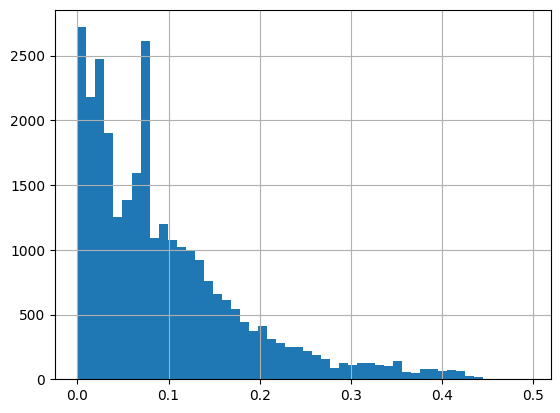

In [135]:
data['pfub_prob_cur'].hist(bins=50) 

In [162]:
import re
class InvoiceDetector():
    def __init__(self):
        self.token_count_th = 10
        self.important_tokens_for_invoice = [
            'rechnung',
            'erinnerung',
            'zahlung',
            'chemnitz',
            'landesjustizkasse',
            'betrag',
            'landeshauptkasse',
            'kassenzeichen',
            'abs',
            'kostenrechnung'
        ]
        pattern = r'\b(' + '|'.join(re.escape(token) for token in self.important_tokens_for_invoice) + r')\b'
        self.token_counting_pattern = re.compile(pattern)

    def extract(self, text: str) -> tuple[bool, int]:
        invoice_token_count = len(self.token_counting_pattern.findall(text.lower()))
        is_invoice_attached = invoice_token_count > self.token_count_th
        return is_invoice_attached, invoice_token_count

In [164]:
pfub = data[data['is_pfub'] == True]
pfub

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date
17211,50220181,ocr_source_files/2026-01-20/egvp_id_294143/502...,pair-data-engineering-new,50220181_Allgemeines_Schreiben_R__20260120_03c...,5a7282c74de38b4592f081d20417fbfa3a21588c79b214...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Köln\n-286a- Amtsgericht Köln, 509...",False,0.00,...,0.00,0.348000,3,0,2026-01-20 10:44:00,False,True,False,True,2026-01-20
17215,50220204,ocr_source_files/2026-01-20/egvp_id_294146/502...,pair-data-engineering-new,50220204_DF-000B49340255C625_FC8E4293-D1AA-490...,3af96ae5f514c5d6166f5fa63566ad50bf3c860443981a...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nAmtsgericht Wittenberg, Postfach ...",False,0.00,...,0.00,0.253333,3,0,2026-01-20 10:44:00,False,True,False,True,2026-01-20
17218,50220232,ocr_source_files/2026-01-20/egvp_id_294151/502...,pair-data-engineering-new,50220232_26_01_20_82M26094-25-PairFinanceGmbH-...,15fba8c03ec6eace6881dc7ac7b109e368d4f863c800eb...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Frankfurt am Main\nMobiliarzwangsv...,False,0.00,...,0.00,0.300000,3,0,2026-01-20 10:44:00,False,True,False,True,2026-01-20
17220,50220240,ocr_source_files/2026-01-20/egvp_id_294153/502...,pair-data-engineering-new,50220240_26_01_20_8M64-26-PairFinanceGmbH-EU_M...,2aca33fe428859a0bd70d1c55587d80b6a607d6748941a...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Bad Schwalbach\nVollstreckungsgeri...,False,0.00,...,0.02,0.248750,3,0,2026-01-20 10:44:00,False,True,False,True,2026-01-20
17225,50219939,ocr_source_files/2026-01-20/egvp_id_294136/502...,pair-data-engineering-new,50219939_4M61_26_GESV-GL_PairFinanceGmbH_70EC2...,3364f178c5530b3a472da9aabe546a60d0055d39d96716...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nWalsrode\nAmtsgericht Walsrode, L...",False,0.01,...,0.00,0.216333,3,0,2026-01-20 10:44:00,False,True,False,True,2026-01-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29256,54150707,ocr_source_files/2026-02-26/egvp_id_316913/541...,pair-data-engineering-new,54150707_10M104_26_VB-GL_PairFinanceGmbH_2BF9F...,1106edef36cf004e7ab5ea9e7d9af974515c8c6ce52dae...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSpringe\nAmtsgericht Springe, Zum...",False,0.01,...,0.01,0.158333,3,0,2026-02-26 15:44:00,False,True,False,True,2026-02-26
29276,54150623,ocr_source_files/2026-02-26/egvp_id_316892/541...,pair-data-engineering-new,54150623_ANSCHR_Pair_Finance_GmbH_Pair_Finance...,86df992aca021615cbd7c937ddc6897dc711d3d5135d48...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Heilbronn\nVOLLSTRECKUNGSGERICHT\n...,False,0.03,...,0.04,0.240000,3,0,2026-02-26 15:44:00,False,True,False,True,2026-02-26
29278,54150632,ocr_source_files/2026-02-26/egvp_id_316895/541...,pair-data-engineering-new,54150632_81M62_26_GESV-GL_PairFinanceGmbH_865A...,53c287842bcdc60f78285faf2e20d0ba8c30b0478eb70d...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht\nOtterndorf\nAmtsgericht Otterndor...,False,0.02,...,0.00,0.168333,3,0,2026-02-26 15:44:00,False,False,False,False,2026-02-26
29342,54203577,ocr_source_files/2026-02-27/egvp_id_317021/542...,pair-data-engineering-new,54203577_20aM474_26_VB-GL_PairFinanceGmbH_E20E...,674932dadc7a811fdd05b7cbc7299bfa572c483651aa2b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nSyke\nAmtsgericht Syke, Amtshof 2...",False,0.02,...,0.00,0.243333,3,0,2026-02-27 06:44:00,False,True,False,True,2026-02-27


In [165]:
pfub.cleaned_text.isna().sum()

np.int64(0)

In [166]:
pfub_invoice_preds = pfub.copy()
pfub_invoice_preds.shape

(1264, 29)

In [167]:
detector = InvoiceDetector()

pfub_invoice_preds['is_invoice_attached'], pfub_invoice_preds['invoice_token_count'] = zip(*pfub_invoice_preds['cleaned_text'].apply(detector.extract))



In [169]:

import plotly.graph_objects as go

counts = pfub_invoice_preds['invoice_token_count']
th_line = 10  # current threshold

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=counts,
    nbinsx=50,
    marker_color='darkorange',
    opacity=0.85,
    name='invoice_token_count',
))

# Threshold vertical line
fig.add_vline(
    x=th_line,
    line_dash='dash',
    line_color='red',
    line_width=2,
    annotation_text=f'Threshold = {th_line}',
    annotation_position='top right',
    annotation_font_color='red',
)

above = (counts >= th_line).sum()
below = (counts < th_line).sum()

fig.update_layout(
    title=dict(
        text=(
            f'Invoice Token Count Distribution (PFUB docs)'
            f'<br><sup>≥{th_line}: {above} docs ({above/len(counts):.1%}) &nbsp;|&nbsp; '
            f'<{th_line}: {below} docs ({below/len(counts):.1%})'
            f' &nbsp;|&nbsp; median={counts.median():.0f}, mean={counts.mean():.1f}</sup>'
        ),
        font=dict(size=16),
    ),
    xaxis_title='Invoice Token Count',
    yaxis_title='Number of Documents',
    template='plotly_white',
    height=460,
    showlegend=False,
    bargap=0.05,
)

fig.show()


In [151]:
check = pfub_invoice_preds[pfub_invoice_preds['invoice_token_count']>=10]
check

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date,is_invoice_attached,invoice_token_count
182,44708175,ocr_source_files/2025-11-23/egvp_id_263636/447...,pair-data-engineering-new,44708175_Dr_ii_1890_25_erfolglose_ermittlung.pdf,2e1e01803b85519f4636d662796f6f1356c0f236d155cb...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin Michels\nAmtsgericht ...,True,NaN,...,4,0,2025-11-23 21:01:25,True,False,False,False,2025-11-23,False,10
603,44748264,ocr_source_files/2025-11-24/egvp_id_264743/447...,pair-data-engineering-new,44748264_Dr_ii_1666_25_aus_schreibmaschine.pdf,9a2d1712296b30690cd0b9555b20bee8a28629cf00535f...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nWendenstraße 3\nPatrick No...,True,NaN,...,5,0,2025-11-24 15:01:29,True,False,False,False,2025-11-24,False,10
620,44750044,ocr_source_files/2025-11-24/egvp_id_264842/447...,pair-data-engineering-new,44750044_Dr_ii_2058_25_erlass_eines_hb_s.pdf,29372bde872051699d41746e30c2ecca72bd70a9952613...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\nWinkeling 24 a\nHeinz-...,True,NaN,...,4,0,2025-11-24 16:01:17,True,False,False,False,2025-11-24,False,10
1134,44900127,ocr_source_files/2025-11-25/egvp_id_265802/449...,pair-data-engineering-new,44900127_Dokumente_97925_25112025_142215_signe...,c9f7f44155c4a58c900c303c2623eccaecb8b6cf2f498b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Janin Ebeling\nOelheimer Str. 16\nObergerichts...,True,NaN,...,6,0,2025-11-25 15:01:18,True,False,False,False,2025-11-25,False,10
1736,45093169,ocr_source_files/2025-11-26/egvp_id_266714/450...,pair-data-engineering-new,45093169_Kostenrechnung_020673503077.pdf,652595358fae29e2df9b2a1ecc4870f81f62da1a582b6e...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,HESSEN\nAmtsgericht Hünfeld\nAmtsgericht Hünfe...,False,NaN,...,1,6,2025-11-26 21:01:22,False,False,False,False,2025-11-26,True,14
2126,45121512,ocr_source_files/2025-11-27/egvp_id_267498/451...,pair-data-engineering-new,45121512_Dr_ii_2177_25_an_gl_nachricht_hbantra...,9c022aeb2934acaff79e051c83f30fa683f1e8a8f48775...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Baden-Württemberg\nGerichtsvollzieher\nAnschri...,True,NaN,...,4,0,2025-11-27 17:01:12,True,False,False,False,2025-11-27,True,13
3395,45581725,ocr_source_files/2025-12-02/egvp_id_269783/455...,pair-data-engineering-new,45581725_0_sammel1.pdf,2dd06616c9a6541ec1ba89e27932ef0faa54da98c13205...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher Diedrich Rohlfs\nDienst...,False,NaN,...,4,0,2025-12-02 18:01:07,False,False,False,False,2025-12-02,False,10
3761,45768229,ocr_source_files/2025-12-03/egvp_id_270866/457...,pair-data-engineering-new,45768229_0_sammel1.pdf,d054c00d542d941138ec28e4d8a65c9ccdcebd2369f3cd...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieher\n48565 Steinfurt\nSchmi...,True,NaN,...,4,0,2025-12-03 15:01:17,True,False,False,False,2025-12-03,True,22
3849,45796685,ocr_source_files/2025-12-03/egvp_id_271113/457...,pair-data-engineering-new,45796685_Dr_ii_419_25_an_gl_mitt_ergebnis_drit...,10f37d95195ecc0e01026be7fdcee57bbba01a77999a08...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\nSchnatweg 11a\nKerst...,True,NaN,...,4,0,2025-12-03 23:01:26,True,False,False,False,2025-12-03,False,10
4140,45820040,ocr_source_files/2025-12-04/egvp_id_271851/458...,pair-data-engineering-new,45820040_0_sammel1.pdf,2fcacc2f3c466e19d876c0db9541bd7b10ed77ebe20e6f...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAnschrift\nUlrich Zillig\n...,True,NaN,...,4,0,2025-12-04 14:01:11,True,False,False,False,202

In [152]:
check['invoice_token_count'].value_counts()

invoice_token_count
10    17
11     9
14     6
20     6
16     6
22     5
19     4
13     2
12     1
Name: count, dtype: int64

In [153]:

import boto3
import os

INVOICE_TOKEN_COUNT = 10
LIMIT = 10

session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')
download_dir = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds"
os.makedirs(download_dir, exist_ok=True)



count_download_dir = os.path.join(download_dir, f"count_{INVOICE_TOKEN_COUNT}")
docs_df = pfub_invoice_preds[pfub_invoice_preds['invoice_token_count']>=INVOICE_TOKEN_COUNT]
os.makedirs(count_download_dir, exist_ok=True)
print(f"\n{'='*60}")
print(f"INVOICE TOKEN COUNT {INVOICE_TOKEN_COUNT} — downloading documents ({min(len(docs_df), LIMIT)} total)")
print(f"{'='*60}")
for _, row in docs_df.iterrows():
    download_pdf_by_document_s3_info(
        s3=s3,
        document_s3_bucket=row['document_s3_bucket'],
        document_s3_key=row['document_s3_key'],
        download_dir=count_download_dir,
    )
    LIMIT -= 1
    if LIMIT == 0:
        break


INVOICE TOKEN COUNT 10 — downloading documents (10 total)
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44708175_Dr_ii_1890_25_erfolglose_ermittlung.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44748264_Dr_ii_1666_25_aus_schreibmaschine.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44750044_Dr_ii_2058_25_erlass_eines_hb_s.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44900127_Dokumente_97925_25112025_142215_signed.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/45093169_Kostenrechnung_020673503077.p

In [115]:
docs_df

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date,is_invoice_attached,invoice_token_count
22810,51882059,ocr_source_files/2026-02-05/egvp_id_304196/518...,pair-data-engineering-new,51882059_4C13_26_PB-KL_RegInkassounternehmenPa...,49ced55b64f21caecb95ddfdaa4bfe2c968a2dc829ede9...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht\nAlfeld\nAmtsgericht Alfeld, Kalan...",False,0.05,...,3,0,2026-02-05 13:44:00,False,True,False,True,2026-02-05,False,4
25143,52684198,ocr_source_files/2026-02-13/egvp_id_309589/526...,pair-data-engineering-new,52684198_Schreiben_b_00_4aae9a5e27cf8022e06362...,6ccc982f12ae6e38fdaa6f01e0f4374f41b612b9a758ef...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Bautzen\nHamtske sudnistwo Budyšin...,False,0.08,...,3,0,2026-02-13 14:44:00,False,True,False,True,2026-02-13,False,4
26307,53305825,ocr_source_files/2026-02-18/egvp_id_311918/533...,pair-data-engineering-new,53305825_Schreiben_b_00_4b147d3b620b8fd8e06361...,c707d3655ca3ac4a9b0bc9e579d41a58617a397efa874d...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Amtsgericht Kamenz\nHamtske sudnistwo\nKamjenc...,False,0.01,...,3,0,2026-02-18 10:44:00,False,True,False,True,2026-02-18,False,4


<Axes: >

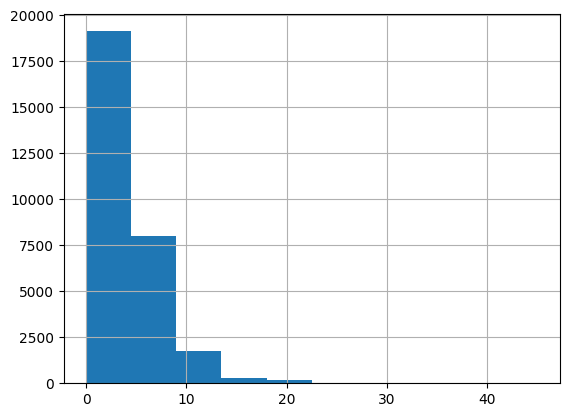

In [221]:
invoice_count_all_data = data.copy()
detector = InvoiceDetector()
invoice_count_all_data['is_invoice_attached'], invoice_count_all_data['invoice_token_count'] = zip(*invoice_count_all_data['cleaned_text'].apply(detector.extract))
invoice_count_all_data['invoice_token_count'].hist()

In [222]:
invoice_token_morethan_10_alldata= data[invoice_count_all_data['invoice_token_count']>=10]
invoice_token_morethan_10_alldata

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,ladung_prob_cur,pfub_prob_cur,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date
0,44528753,ocr_source_files/2025-11-21/egvp_id_263308/445...,pair-data-engineering-new,44528753_Dr_ii_788_25_aus_schreibmaschine.pdf,67060082c28ff4555915be5927987865ee1585937169a3...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Gerichtsvollzieher\nAG Pasewalk\nThomas Rex\nZ...,True,NaN,...,0.01,0.12,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
1,44528842,ocr_source_files/2025-11-21/egvp_id_263329/445...,pair-data-engineering-new,44528842_Dokument_154725_21112025_144339.pdf,0ff17f8cc5a190950a30811e7625188371ba5d4e2d1cab...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Katharina Hahn\nHerrenstraße 11\nObergerichtsv...,False,NaN,...,0.06,0.00,1,0,2025-11-21 15:59:17,False,False,False,False,2025-11-21
15,44528764,ocr_source_files/2025-11-21/egvp_id_263309/445...,pair-data-engineering-new,44528764_Protokoll_GKB-EV21_19_11_2025__Gl_.pdf,e9aa64c7f95b93fa63717116455de13d0f6984b4b5aaf6...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,RICHARD STIPP\nDie nachstehend gewählten Formu...,True,NaN,...,0.00,0.03,4,0,2025-11-21 15:59:17,True,False,False,False,2025-11-21
19,44529791,ocr_source_files/2025-11-21/egvp_id_263440/445...,pair-data-engineering-new,44529791_2025-11-18_Protokoll_GKB-EV21.pdf,e54bbea710c91747f5ea679ac6dc4134a514c9a4ef23c2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,ANDRÉ EBERT\nDie nachstehend gewählten Formuli...,True,NaN,...,0.00,0.04,4,0,2025-11-21 16:06:58,True,False,False,False,2025-11-21
39,44529743,ocr_source_files/2025-11-21/egvp_id_263426/445...,pair-data-engineering-new,44529743_Protokoll_GKB-EV21_19_11_2025__Gl_.pdf,9122d7a9547bd2da13721c9b3f40ca9e0825c026c5c50b...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Linda Schlüter\nDie nachstehend gewählten Form...,True,NaN,...,0.00,0.00,4,0,2025-11-21 16:06:58,True,False,False,False,2025-11-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29259,54150717,ocr_source_files/2026-02-26/egvp_id_316916/541...,pair-data-engineering-new,54150717_Sammeldokument_DRNr_23326_26022026-si...,76df213babd97ba9f268ac2697dcd8e03948d34147fb18...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,T. Freimuth\nPostfach 40 01 18\nGerichtsvollzi...,False,0.05,...,0.04,0.09,6,0,2026-02-26 15:44:00,False,False,False,False,2026-02-26
29269,54150698,ocr_source_files/2026-02-26/egvp_id_316910/541...,pair-data-engineering-new,54150698_DR-II_043426_Nachr_Ablehnung_Vollstre...,d0dbfe4cc0aebc77a1350302d6fb5090b9c52e47383fa2...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Waisenstraße 13\nS. Brenz\n09111 Chemnitz\nObe...,False,0.36,...,0.10,0.03,4,0,2026-02-26 15:44:00,False,False,False,False,2026-02-26
29280,54150637,ocr_source_files/2026-02-26/egvp_id_316896/541...,pair-data-engineering-new,54150637_Dr_ii_217_26_aus_schreibmaschine.pdf,16e0e4232cb6817a801762e0533d8cc503dbac7119020d...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Obergerichtsvollzieherin\n38100 Braunschweig\n...,False,0.10,...,0.04,0.17,4,0,2026-02-26 15:44:00,False,False,False,False,2026-02-26
29295,54152287,ocr_source_files/2026-02-26/egvp_id_316951/541...,pair-data-engineering-new,54152287_Protokoll_GKB-EV21_26_02_2026.pdf,0e4599181cbd55eb3e79256198d894060d4d44eae79919...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,Nicole Späth\nDie nachstehend gewählten Formul...,False,0.00,...,0.00,0.00,4,0,2026-02-26 16:44:00,False,False,False,False,2026-02-26


In [223]:

import boto3
import os

LIMIT = 20

session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')
download_dir = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample"
os.makedirs(download_dir, exist_ok=True)

sample_docs = invoice_token_morethan_10_alldata.sample(n=min(LIMIT, len(invoice_token_morethan_10_alldata)), random_state=42)

print(f"Downloading {len(sample_docs)} examples from invoice_token_morethan_10_alldata")
for _, row in sample_docs.iterrows():
    download_pdf_by_document_s3_info(
        s3=s3,
        document_s3_bucket=row['document_s3_bucket'],
        document_s3_key=row['document_s3_key'],
        download_dir=download_dir,
    )
print("Done.")


INFO [2026-03-04 15:55:37] - Found credentials in shared credentials file: ~/.aws/credentials


✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample/50766151_Dokumente_112324_26012026_133901.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample/46538690_Dokument_116924_12122025_081713.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample/53759143_Dokument_20526_23022026_141456.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample/45768172_Dokument_43125_03122025_100253.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/full_data_invoice_algo_sample/47480070_Protokoll_GKB-EV21_10_12_2025__Gl_.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automati

In [132]:
invoice_token_morethan_10_alldata.kmeans_cluster.value_counts()

kmeans_cluster
4    998
1    360
5    135
6     93
2      1
7      1
Name: count, dtype: int64

<Axes: >

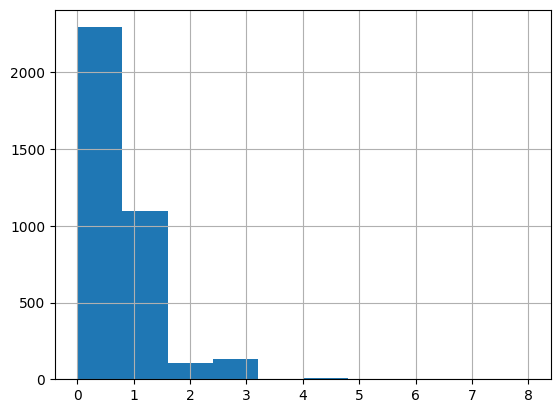

In [155]:
invoice_count_all_data_cluster_3 = invoice_count_all_data[invoice_count_all_data['kmeans_cluster'] == 3]
invoice_count_all_data_cluster_3['invoice_token_count'].hist()

In [156]:
invoice_count_all_data_cluster_3['invoice_token_count'].value_counts()

invoice_token_count
0    2294
1    1097
3     131
2     108
4      11
8       1
5       1
Name: count, dtype: int64

,attachment_id,document_s3_key,document_s3_bucket,file_name,textract_job_id,textract_status,textract_s3_link,text,is_ladung,ladung_prob,...,kmeans_cluster,dbscan_cluster,created_at,ladung_all_params_exist,pfub_all_params_exist,automized_as_ladung,automized_as_pfub,created_date,is_invoice_attached,invoice_token_count
4831,46105885,ocr_source_files/2025-12-08/egvp_id_273780/461...,pair-data-engineering-new,46105885_Beschluss_66752751-36b5-4432-a0ba-ab8...,399251b98f5bdc3cc99e8be11001cc76884d01cd190cce...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,08 M 1978/25\nAmtsgericht Dinslaken\nBeschluss...,False,NaN,...,3,-1,2025-12-08 10:01:09,False,False,False,False,2025-12-08,False,8
22652,51871607,ocr_source_files/2026-02-05/egvp_id_303698/518...,pair-data-engineering-new,51871607_Schreiben_Schreiben_vom_05_02_2026_fo...,636c88503e9d82c7c7dfde8074031831ad953dc27c66ff...,SUCCEEDED,s3://pair-data-engineering-new/ocr_prepared_ou...,"Amtsgericht Reinbek\nAmtsgericht Reinbek, PF 1...",False,0.06,...,3,-1,2026-02-05 10:44:00,False,False,False,False,2026-02-05,False,5


In [161]:
download_docs = invoice_count_all_data_cluster_3[invoice_count_all_data_cluster_3['invoice_token_count']>=3]
download_docs
import boto3
import os

INVOICE_TOKEN_COUNT = 10
LIMIT = 10

session = boto3.Session(profile_name='739275445236_DataScienceUser')
s3 = session.client('s3')
download_dir = "/Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds"
os.makedirs(download_dir, exist_ok=True)



count_download_dir = os.path.join(download_dir, f"count_{INVOICE_TOKEN_COUNT}")
os.makedirs(count_download_dir, exist_ok=True)
print(f"\n{'='*60}")
print(f"INVOICE TOKEN COUNT {INVOICE_TOKEN_COUNT} — downloading documents ({min(len(download_docs), LIMIT)} total)")
print(f"{'='*60}")
for _, row in download_docs.iterrows():
    download_pdf_by_document_s3_info(
        s3=s3,
        document_s3_bucket=row['document_s3_bucket'],
        document_s3_key=row['document_s3_key'],
        download_dir=count_download_dir,
    )
    LIMIT -= 1
    if LIMIT == 0:
        break


INVOICE TOKEN COUNT 10 — downloading documents (10 total)
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44528839_9C570_25_KL_LiquandumCapitalIIGmbHgesetzlvertrddG_B8D8C68C-F90E-4B81-8F71-8AAF9BC08C61.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44733640_ANSCHR_24_11_2025_b_00_4451090a9c991464e063623011ac81c0.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/44745812_ANSCHR_24_11_2025_b_00_4451a8ef98bfd706e063623011ac6f06.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/Desktop/Projects/aftercourt_automation/assets/pdfs/tmp/invoice_token_count_preds/count_10/45081371_70M1995_25_-GL_PairFinanceGmbH_EBC0119C-13B9-4FAB-B22D-CEF1EFC3F220.pdf
✅ PDF downloaded successfully: /Users/melih.gorgulu/De

Idea: we also have pfub preds from incoming mail attachmets. Lets checkt that, i think its likely to have some pfub docs with invoice attached there

In [170]:
from python_utilities.db_connection import DbConnection
analytics_db = DbConnection('ANALYTICS', 'PROD_RDS')
lap_pfubs = analytics_db.sql_to_df(f"""
    SELECT *
    FROM llm_attachments_predictions lap
    WHERE lap.type = "aftercourt_classification_pfub" AND lap.subtype='class_prob'
""")

INFO [2026-03-04 15:17:00] - PYTHON_UTILITIES - secret_utilities.py - get_db_secret_config - Credentials for database were read from secret.ini file


In [174]:
lap_pfubs['pfub_prob'] = lap_pfubs['value'].apply(lambda x: float(x.replace("'", "")) if x is not None else None)

In [175]:
lap_pfubs['pfub_prob'].isna().sum()

np.int64(0)

In [177]:
pfub_attachments = lap_pfubs[lap_pfubs['pfub_prob']>=0.3]

In [178]:
pfub_attachments

,id,created_at,model_name,type,subtype,value,attachment_id,pfub_prob
417,3086930,2026-01-20 16:43:18,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.56',24951202107292-1,0.560000
499,3087970,2026-01-20 16:44:14,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.4075',24951654897564-3,0.407500
583,3089089,2026-01-20 16:45:15,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.563',24951946854172-1,0.563000
793,3091719,2026-01-20 16:47:37,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.35095238095238096',24952829909788-2,0.350952
886,3093034,2026-01-20 16:48:48,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.7366666666666666',24953091901724-5,0.736667
...,...,...,...,...,...,...,...,...
156450,5373564,2026-03-04 13:17:38,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',54911288,0.990000
156462,5373647,2026-03-04 13:17:42,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.98',54913585,0.980000
156464,5373661,2026-03-04 13:17:43,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.545',54913599,0.545000
156468,5373690,2026-03-04 13:17:44,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.8666666666666666',54913623,0.866667


In [181]:
# get the mail attachments
pfub_attachments_mail = pfub_attachments[~pfub_attachments['attachment_id'].str.contains("-")]
pfub_attachments_mail

,id,created_at,model_name,type,subtype,value,attachment_id,pfub_prob
898,3093187,2026-01-20 16:48:56,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.37',50219849,0.370000
900,3093202,2026-01-20 16:48:57,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219877,0.990000
903,3093227,2026-01-20 16:48:58,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.49873809523809515',50219891,0.498738
904,3093233,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219898,0.990000
905,3093241,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.34166666666666673',50219903,0.341667
...,...,...,...,...,...,...,...,...
156450,5373564,2026-03-04 13:17:38,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',54911288,0.990000
156462,5373647,2026-03-04 13:17:42,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.98',54913585,0.980000
156464,5373661,2026-03-04 13:17:43,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.545',54913599,0.545000
156468,5373690,2026-03-04 13:17:44,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.8666666666666666',54913623,0.866667


In [182]:
pfub_attachments_mail['attachment_id'].isna().sum()

np.int64(0)

In [187]:
pfub_attachments_mail['attachment_id'].is_unique

True

In [191]:
import sys
import os
import glob

import boto3
sys.path.append('../../')

from utils.prod_utils import get_data_by_attachment_id


attachment_ids_to_fetch = pfub_attachments_mail['attachment_id'].tolist()

In [198]:
a_id_to_text = dict()
for attachment_id in attachment_ids_to_fetch:
    cur_attch_data = get_data_by_attachment_id(attachment_id, analytics_db, s3, verbose=False)
    text = cur_attch_data.iloc[0]['text']
    a_id_to_text[attachment_id] = text

In [203]:
pfub_attachments_mail = pfub_attachments_mail.copy()
pfub_attachments_mail['attachment_id'] = pfub_attachments_mail['attachment_id'].astype(str)
a_id_to_text = {str(k): v for k, v in a_id_to_text.items()}
pfub_attachments_mail['text'] = pfub_attachments_mail['attachment_id'].map(a_id_to_text)
pfub_attachments_mail

,id,created_at,model_name,type,subtype,value,attachment_id,pfub_prob,text
898,3093187,2026-01-20 16:48:56,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.37',50219849,0.370000,Amtsgericht Detmold\n-9- Amtsgericht Detmold P...
900,3093202,2026-01-20 16:48:57,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219877,0.990000,Amtsgericht Essen-Borbeck\n-Geschäftsstelle-\n...
903,3093227,2026-01-20 16:48:58,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.49873809523809515',50219891,0.498738,RheinlandPfalz\nAMTSGERICHT\nWITTLICH\nAmtsger...
904,3093233,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219898,0.990000,"Amtsgericht Essen\n-30- Amtsgericht Essen, 451..."
905,3093241,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.34166666666666673',50219903,0.341667,RheinlandPfalz\nAMTSGERICHT\nLANDSTUHL\nAmtsge...
...,...,...,...,...,...,...,...,...,...
156450,5373564,2026-03-04 13:17:38,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',54911288,0.990000,Amtsgericht Bad Oeynhausen\n-140- Amtsgericht ...
156462,5373647,2026-03-04 13:17:42,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.98',54913585,0.980000,"Amtsgericht Köln\n-288a- Amtsgericht Köln, 509..."
156464,5373661,2026-03-04 13:17:43,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.545',54913599,0.545000,Amtsgericht Rastatt\nVOLLSTRECKUNGSGERICHT\nAm...
156468,5373690,2026-03-04 13:17:44,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.8666666666666666',54913623,0.866667,"Amtsgericht Moers\n-503- Amtsgericht Moers, Ha..."


In [204]:
pfub_attachments_mail.pfub_prob.max()

np.float64(1.0)

In [205]:
pfub_attachments_mail.pfub_prob.min()

np.float64(0.3)

In [206]:
pfub_attachments_mail.created_at.min(), pfub_attachments_mail.created_at.max()

(Timestamp('2026-01-20 16:48:56'), Timestamp('2026-03-04 13:17:51'))

In [208]:
pfub_attachments_mail

,id,created_at,model_name,type,subtype,value,attachment_id,pfub_prob,text
898,3093187,2026-01-20 16:48:56,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.37',50219849,0.370000,Amtsgericht Detmold\n-9- Amtsgericht Detmold P...
900,3093202,2026-01-20 16:48:57,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219877,0.990000,Amtsgericht Essen-Borbeck\n-Geschäftsstelle-\n...
903,3093227,2026-01-20 16:48:58,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.49873809523809515',50219891,0.498738,RheinlandPfalz\nAMTSGERICHT\nWITTLICH\nAmtsger...
904,3093233,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',50219898,0.990000,"Amtsgericht Essen\n-30- Amtsgericht Essen, 451..."
905,3093241,2026-01-20 16:48:59,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.34166666666666673',50219903,0.341667,RheinlandPfalz\nAMTSGERICHT\nLANDSTUHL\nAmtsge...
...,...,...,...,...,...,...,...,...,...
156450,5373564,2026-03-04 13:17:38,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.99',54911288,0.990000,Amtsgericht Bad Oeynhausen\n-140- Amtsgericht ...
156462,5373647,2026-03-04 13:17:42,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.98',54913585,0.980000,"Amtsgericht Köln\n-288a- Amtsgericht Köln, 509..."
156464,5373661,2026-03-04 13:17:43,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.545',54913599,0.545000,Amtsgericht Rastatt\nVOLLSTRECKUNGSGERICHT\nAm...
156468,5373690,2026-03-04 13:17:44,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.8666666666666666',54913623,0.866667,"Amtsgericht Moers\n-503- Amtsgericht Moers, Ha..."


In [209]:
from utils.intent_recog_utils import apply_text_cleaning

In [210]:
pfub_attachments_mail['cleaned_text'] = pfub_attachments_mail['text'].apply(apply_text_cleaning)

apply invoice detection algorithm to this dataset 

In [212]:
import re
class InvoiceDetector():
    def __init__(self):
        self.token_count_th = 10
        self.important_tokens_for_invoice = [
            'rechnung',
            'erinnerung',
            'zahlung',
            'chemnitz',
            'landesjustizkasse',
            'betrag',
            'landeshauptkasse',
            'kassenzeichen',
            'abs',
            'kostenrechnung'
        ]
        pattern = r'\b(' + '|'.join(re.escape(token) for token in self.important_tokens_for_invoice) + r')\b'
        self.token_counting_pattern = re.compile(pattern)

    def extract(self, text: str) -> tuple[bool, int]:
        invoice_token_count = len(self.token_counting_pattern.findall(text.lower()))
        is_invoice_attached = invoice_token_count > self.token_count_th
        return is_invoice_attached, invoice_token_count
    
detector = InvoiceDetector()

In [213]:
# apply the detector to the cleaned text
pfub_attachments_mail['is_invoice_attached'], pfub_attachments_mail['invoice_token_count'] = zip(*pfub_attachments_mail['cleaned_text'].apply(detector.extract))

In [218]:
pfub_attachments_mail['invoice_token_count'].value_counts()

invoice_token_count
0     917
1     574
3      83
2      31
4       3
14      1
5       1
13      1
Name: count, dtype: int64

In [214]:
pfub_attachments_mail['is_invoice_attached'].value_counts()

is_invoice_attached
False    1609
True        2
Name: count, dtype: int64

In [220]:
check = pfub_attachments_mail[pfub_attachments_mail['invoice_token_count']>3]
check

,id,created_at,model_name,type,subtype,value,attachment_id,pfub_prob,text,cleaned_text,is_invoice_attached,invoice_token_count
3757,3127857,2026-01-21 02:08:48,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.4',50227946,0.400000,HESSEN\nAmtsgericht Wiesbaden\nAmtsgericht Wie...,hessen\namtsgericht wiesbaden\namtsgericht wie...,True,14
60698,3955521,2026-02-05 16:46:34,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.4858928571428571',51871607,0.485893,"Amtsgericht Reinbek\nAmtsgericht Reinbek, PF 1...","amtsgericht reinbek\namtsgericht reinbek, pf 1...",False,5
61606,3967979,2026-02-05 18:07:51,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.515',51882059,0.515000,"Amtsgericht\nAlfeld\nAmtsgericht Alfeld, Kalan...","amtsgericht\nalfeld\namtsgericht alfeld, kalan...",False,4
91366,4409807,2026-02-13 21:06:53,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.5575',52684198,0.557500,Amtsgericht Bautzen\nHamtske sudnistwo Budyšin...,amtsgericht bautzen\nhamtske sudnistwo budyšin...,False,4
105252,4616809,2026-02-18 15:09:57,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.56',53305825,0.560000,Amtsgericht Kamenz\nHamtske sudnistwo\nKamjenc...,amtsgericht kamenz\nhamtske sudnistwo\nkamjenc...,False,4
155349,5356983,2026-03-03 23:20:02,aftercourt_classification_pfub,aftercourt_classification_pfub,class_prob,'0.3',54839623,0.300000,HESSEN\nAmtsgericht Limburg a. d. Lahn\nAmtsge...,hessen\namtsgericht limburg a. d. lahn\namtsge...,True,13
